# **Database Monitoring Script - Cocaine Seizures (2025)**
#### InSight Crime - MAD Unit 

---------------------


## Setup

#### Version Control

The project is created within a single GitHub repository ([FelipeVillota/db-check](https://github.com/FelipeVillota/db-check-cocaine-seizures)). I keep the repository `private` with the possibility to give access to the online repo at any time. 

#### Environment

In [4]:
import os
import subprocess
import sys

# Subprocess Scripting Automation to manage and reproduce Python virtual environment and prepare packages

# Define environment name and path
venv_name = "venv-db-check"
venv_path = os.path.join(os.getcwd(), venv_name)

# 1. Create the virtual environment if it doesn't exist
if not os.path.exists(venv_path):
    # On Linux Mint, ensure python3-venv is installed
    try:
        subprocess.run([sys.executable, "-m", "venv", venv_path], check=True)
        print(f"✅ Created virtual environment: {venv_name}")
    except subprocess.CalledProcessError as e:
        sys.exit(1)
else:
    print(f"✅ Virtual environment '{venv_name}' already exists.")

# 2. Define the venv's python executable (Linux-specific)
venv_python = os.path.join(venv_path, "bin", "python")

# Safety check with more descriptive error
if not os.path.exists(venv_python):
    raise FileNotFoundError(
        f"Python executable not found at {venv_python}\n"
        "If you're on Linux Mint, ensure the virtual environment was created properly."
    )

# 3. Install and upgrade packages using the venv's Python, only if needed
packages = [
    "gspread", "pandas", "requests", "google-api-python-client",
    "oauth2client", "matplotlib", "seaborn", "missingno",
    "gspread-formatting", "ipykernel", "openpyxl"
]

# Get list of already installed packages
try:
    result = subprocess.run(
        [venv_python, "-m", "pip", "freeze"],
        capture_output=True, text=True, check=True
    )
    installed_packages = result.stdout.lower()
except subprocess.CalledProcessError:
    installed_packages = ""
    print("⚠️ No packages installed yet in virtual environment")

# Check if all required packages are already installed
missing = [pkg for pkg in packages if not any(pkg.lower() in line for line in installed_packages.splitlines())]

if missing:
    print(f"⚠️ Missing packages: {missing}")
    subprocess.run([venv_python, "-m", "pip", "install", "--upgrade", "pip"], check=True)
    subprocess.run([venv_python, "-m", "pip", "install"] + missing, check=True)
    print("✅ Installed missing packages into virtual environment")
else:
    print("✅ All required packages already installed — skipping installation.")

# 4. Register the venv as a Jupyter kernel
kernel_name = "db-check"
display_name = "Python (db-check)"

try:
    subprocess.run([
        venv_python, "-m", "ipykernel", "install", "--user",
        "--name", kernel_name,
        "--display-name", display_name
    ], check=True)
    print(f"✅ Registered Jupyter kernel: {display_name}")
except subprocess.CalledProcessError as e:
    print("Failed to register Jupyter kernel. On Linux Mint, you may need to install jupyter first:")
    print("Try running: sudo apt install jupyter-core")
    sys.exit(1)

# 5. Print the Python executable path being used
print("Python executable:", venv_python)

# 6. Freeze the current package list to requirements.txt
requirements_path = os.path.join(os.getcwd(), "requirements.txt")
with open(requirements_path, "w") as f:
    subprocess.run([venv_python, "-m", "pip", "freeze"], stdout=f, check=True)
print(f"✅ requirements.txt created at {requirements_path}")

✅ Created virtual environment: venv-db-check
⚠️ Missing packages: ['gspread', 'pandas', 'requests', 'google-api-python-client', 'oauth2client', 'matplotlib', 'seaborn', 'missingno', 'gspread-formatting', 'ipykernel', 'openpyxl']
  Using cached pip-25.2-py3-none-any.whl.metadata (4.7 kB)
Using cached pip-25.2-py3-none-any.whl (1.8 MB)
  Attempting uninstall: pip
    Found existing installation: pip 24.0
    Uninstalling pip-24.0:
      Successfully uninstalled pip-24.0
  Using cached gspread-6.2.1-py3-none-any.whl.metadata (11 kB)
  Using cached pandas-2.3.1-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (91 kB)
  Using cached requests-2.32.4-py3-none-any.whl.metadata (4.9 kB)
  Using cached google_api_python_client-2.179.0-py3-none-any.whl.metadata (7.0 kB)
  Using cached oauth2client-4.1.3-py2.py3-none-any.whl.metadata (1.2 kB)
  Using cached matplotlib-3.10.5-cp312-cp312-manylinux2014_x86_64.manylinux_2_17_x86_64.whl.metadata (11 kB)
  Using cached seaborn-0.13.2

In [1]:
import os
from datetime import datetime

# Get current date
print("Current Date:", datetime.now().strftime("%Y-%m-%d %H:%M:%S"))

# Count items, files, and directories
items = os.listdir()
files = [f for f in items if os.path.isfile(f)]
directories = [d for d in items if os.path.isdir(d)]

print(f"Total Items: {len(items)}")
print(f"Files: {len(files)}")
print(f"Directories: {len(directories)}")

# Get files sorted by modification time 
print("\nJust files (newest first):")
files_with_mtime = [(f, os.path.getmtime(f)) for f in items if os.path.isfile(f)]
sorted_files = sorted(files_with_mtime, key=lambda x: x[1], reverse=True)

for file, mtime in sorted_files:
    print(f"{datetime.fromtimestamp(mtime)} - {file}")

Current Date: 2025-08-18 16:26:40
Total Items: 6
Files: 3
Directories: 3

Just files (newest first):
2025-08-18 16:26:38.894249 - script.ipynb
2025-08-18 16:26:14.843948 - requirements.txt
2025-08-17 21:30:39.197024 - README.md


#### Libraries

In [2]:
import re
import requests
import pandas as pd
from datetime import datetime
from google.oauth2 import service_account
from googleapiclient.discovery import build
import gspread
from google.oauth2.service_account import Credentials
from gspread_formatting import format_cell_ranges, CellFormat, Color
import matplotlib.pyplot as plt
import seaborn as sns
import missingno as msno
import openpyxl as px

### API

This creates a modular client (frontend) call that is able to extract the desired subset of data from the API server (backend); -and, make it easily reusable for future queries.


In [16]:
# Configure Google Drive API

# Path to your service account key file
SERVICE_ACCOUNT_FILE = '/home/lfvm/Desktop/codebaker/nyckelring/brelok/summer-sector-439022-v6-2eafffbbfb90.json' # Update with the actual path or team credentials file

# VERY IMPORTANT: Ensure the service account has access to the Google Sheet by sharing it with the service account email

# Original (latest version) Google Sheet ID
ORIGINAL_SPREADSHEET_ID =  '1t61MafCmnRe2QN082Bk1V0IxBSIW8UUqH1g5mULgb2o' # CAUTION

TEST_SPREADSHEET_ID = ''

# Define the sheet tab or range to read
RANGE_NAME = '2025' # CAUTION

# Define scopes for Google Sheets and Drive API
SCOPES = ['https://www.googleapis.com/auth/spreadsheets', 
          'https://www.googleapis.com/auth/drive']

In [17]:
# Authenticate and build both Sheets and Drive services
creds = service_account.Credentials.from_service_account_file(
    SERVICE_ACCOUNT_FILE, scopes=SCOPES)
sheet_service = build('sheets', 'v4', credentials=creds)
drive_service = build('drive', 'v3', credentials=creds)

In [18]:
# Verify last modifying user and time of the original spreadsheet. This information is related to the file itself, not to specific content (sheets, cells, rows)

from googleapiclient.discovery import build
from datetime import datetime
import pytz

def get_last_modifying_user(drive_service, file_id):
    try:
        # Get revisions (only the last one)
        revisions = drive_service.revisions().list(
            fileId=file_id,
            fields="revisions(modifiedTime,lastModifyingUser)"
        ).execute().get('revisions', [])
        
        if not revisions:
            return "No revisions found."
        
        last_revision = revisions[-1]  # Most recent revision
        user_info = last_revision.get('lastModifyingUser', {})
        email = user_info.get('emailAddress', 'Unknown')
        modified_time = last_revision.get('modifiedTime', 'Unknown')
        
        # Convert to readable datetime
        if modified_time != 'Unknown':
            dt = datetime.strptime(modified_time, "%Y-%m-%dT%H:%M:%S.%fZ")
            dt = dt.replace(tzinfo=pytz.UTC)
            modified_time = dt.strftime("%Y-%m-%d %H:%M:%S (UTC)")
        
        return {
            "user_email": email,
            "modified_time": modified_time
        }
    
    except Exception as e:
        return f"Error: {str(e)}"

# Usage
# First get the file name and sheet name
file_metadata = drive_service.files().get(fileId=ORIGINAL_SPREADSHEET_ID, fields='name').execute()
file_name = file_metadata.get('name', 'Unknown')

# Get sheet names
sheets = sheet_service.spreadsheets().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    fields='sheets(properties(title))'
).execute().get('sheets', [])

sheet_names = [sheet['properties']['title'] for sheet in sheets]

# Get last modifier info
last_modifier = get_last_modifying_user(drive_service, ORIGINAL_SPREADSHEET_ID)


print(
    f"📄 File name: {file_name}\n"
    f"📑 Sheet names: {', '.join(sheet_names)}\n"
    f"🔄 Last modified by: {last_modifier['user_email']}\n"
    f"⏰ Last modified at: {last_modifier['modified_time']}"
)

📄 File name: incautaciones cocaina 01-02
📑 Sheet names: Seizures, Guide, 2025, 2024, VRAEM, 2023, Primary Sources, origins, db-test
🔄 Last modified by: mpeters@insightcrime.org
⏰ Last modified at: 2025-08-17 07:16:07 (UTC)


### Import Data

In [19]:
# Loading data as df
 
# Call the Sheets API to read data
sheet = sheet_service.spreadsheets()
result = sheet.values().get(spreadsheetId=ORIGINAL_SPREADSHEET_ID, range=RANGE_NAME).execute()
values = result.get('values', [])

# Convert to DataFrame for easier manipulation
df = pd.DataFrame(values[1:], columns=values[0])
print(df.head()) 

      Type   Time unit        Date Date 2  Year Month Day Duration  \
0  Seizure  Individual  2025-03-24         2025     3  24            
1  Seizure  Individual  2025-03-23         2025     3  23            
2  Seizure  Individual  2025-03-22         2025     3  22            
3  Seizure  Individual  2025-03-22         2025     3  22            
4  Seizure  Individual  2025-03-19         2025     3  19            

                       Type Drugs Quantity  ... Destition - department.state  \
0                         Cocaine       10  ...                                
1                         Cocaine      2.5  ...                                
2                         Cocaine     2619  ...                                
3  Other (explain in Description)     1240  ...                                
4                         Cocaine    16.05  ...                                

  Destition - Municipality/Port Destition 2 - Country  \
0                                        

### Pre-process

In [20]:
# Handle Missing/Invalid Values. We want to keep this step as simple as possible, as we will be changing the data structure later.
 
df = df.replace('', pd.NA)  # Convert empty strings to NA
df = df.replace(r'^\s*$', pd.NA, regex=True)  # Convert whitespace to NA
print("✓ Converted empty strings/whitespace to NA values")

✓ Converted empty strings/whitespace to NA values


In [21]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, RANGE_NAME, creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 Type: ['Total Production Estimate', 'Seizure', 'Crop Eradication', 'Total Crop Cultivation Estimate', 'Other (explain in Description)', 'Price']
🔽 Time unit: ['Multi-Month', 'Individual', 'Multi-Year', 'Other (explain in Description)', 'Year', 'Month']
🔽 Type Drugs: ['All/Unspecified/Multiple', 'Cocaine Base', 'Other (explain in Description)', 'Coca Crops', 'Cocaine - Crack', 'Cocaine']
🔽 Weight unit: ['Kilogram', 'Euro', 'USD', 'Pounds (lbs)', 'Hectare', 'Package', 'Other currency (say which in Description)', 'Other (explain in Description)', 'Plant', 'Pounds (£)', 'Percent']
🔽 Modus Operandi/place of seizure: ['Maritime vessel', 'Air', 'Land', 'Container', 'River vessel']
🔽 Region: ['Global', 'Central America', 'Africa', 'North America', 'Oceania', 'Caribbean', 'South America', 'Asia', 'Europe']
🔽 Origin country: ['Peru', 'Bolivia', '""', 'Colombia']
🔽 Transit 1/Region: ['Global', 'Central America', 'Africa', 'North America', 'Oceania', 'Australia', 'Caribbean', 'South America', 'A

## Monitoring

##### Summary Stats

In [22]:
def get_dataframe_summary(df):
    
    # --- General DataFrame Info ---
    general_info = {
        "Shape": f"{df.shape[0]} rows × {df.shape[1]} cols",
        "Memory Usage": f"{df.memory_usage(deep=True).sum() / (1024 ** 2):.2f} MB",
        "Columns with NA": f"{df.isna().any().sum()} of {len(df.columns)}",
        "Duplicate Rows": f"{df.duplicated().sum()} ({(df.duplicated().mean() * 100):.1f}%)",
        "Numeric Columns": f"{df.select_dtypes(include='number').shape[1]}",
        "Categorical Columns": f"{df.select_dtypes(include=['object', 'category']).shape[1]}",
        "Datetime Columns": f"{df.select_dtypes(include='datetime').shape[1]}"
    }

    # --- Compute dropdown options per column ---
    dropdown_options_dict = {
        col: dropdown_options.get(col, [])
        for col in df.columns
    }
    
    # --- Column-Level Stats ---
    column_stats = pd.DataFrame({
        'Variable': df.columns,
        'Dtype': df.dtypes.values,
        'Unique_Count': df.nunique().values,
        'NA_Count': df.isna().sum().values,
        'NA_Percentage': (df.isna().mean() * 100).round(1).values,
        'Duplicate_Count': df.apply(lambda col: col.duplicated(keep=False).sum()).values,
        'Duplicate_Percentage': (df.apply(lambda col: col.duplicated(keep=False).mean()) * 100).round(1).values,
        'Unique_Values': df.apply(lambda x: x.drop_duplicates().tolist()).values,
        'Dropdown_Options': [dropdown_options_dict[col] for col in df.columns],
        'Dropdown_Option_Count': [len(dropdown_options_dict[col]) for col in df.columns]
    }).sort_values('Unique_Count', ascending=False)


    # --- Format percentages ---
    column_stats['NA_Percentage'] = column_stats['NA_Percentage'].astype(str) + '%'
    column_stats['Duplicate_Percentage'] = column_stats['Duplicate_Percentage'].astype(str) + '%'

    return general_info, column_stats

# Run the summary
general_info, column_stats = get_dataframe_summary(df)

# Print General Info
print("=== GENERAL DATAFRAME INFO ===")
for key, value in general_info.items():
    print(f"{key}: {value}")

# Display Column Stats (including dropdown options)
print("\n=== COLUMN-LEVEL STATISTICS ===")
display(column_stats)


=== GENERAL DATAFRAME INFO ===
Shape: 718 rows × 41 cols
Memory Usage: 1.81 MB
Columns with NA: 41 of 41
Duplicate Rows: 0 (0.0%)
Numeric Columns: 0
Categorical Columns: 41
Datetime Columns: 0

=== COLUMN-LEVEL STATISTICS ===


,Variable,Dtype,Unique_Count,NA_Count,NA_Percentage,Duplicate_Count,Duplicate_Percentage,Unique_Values,Dropdown_Options,Dropdown_Option_Count
35,Description,object,712,3,0.4%,8,1.1%,"[Spanish citizen, coming from Lisbon , was sto...",[],0
39,Source link,object,690,1,0.1%,50,7.0%,[https://www.lanazione.it/firenze/cronaca/coca...,[],0
17,Municipality/Port,object,442,164,22.8%,337,46.9%,"[Florence, Santo Domingo, Lake Maracaibo , Eag...",[],0
9,Quantity,object,438,4,0.6%,397,55.3%,"[10, 2.5, 2619, 1240, 16.05, 65, 6600, 142, 55...",[],0
11,seizure_kgs,object,362,161,22.4%,455,63.4%,"[9, 2.5, 2619, 1240, 16.05, 65, 6600, 142, 250...",[],0
16,Department/State,object,319,69,9.6%,515,71.7%,"[<NA>, Zulia, Texas, Cáceres, Azores, Québec, ...",[],0
13,Sub MO,object,154,562,78.3%,565,78.7%,"[Liquid cocaine, <NA>, Production laboratory, ...",[],0
2,Date,object,152,3,0.4%,693,96.5%,"[2025-03-24, 2025-03-23, 2025-03-22, 2025-03-1...",[],0
24,Transit 1/Municipality,object,97,601,83.7%,636,88.6%,"[<NA>, Matapalo, Rio de Janeiro, Acapulco, Kin...",[],0
23,Transit 1/Department,object,77,587,81.8%,659,91.8%,"[Lisbon, <NA>, Santo Domingo, Paris, Puntarena...",[],0


##### Missing Data


Missing values per column:
Type                                 1
Time unit                            1
Date                                 3
Date 2                             703
Year                                 3
Month                                3
Day                                  4
Duration                           702
Type Drugs                           1
Quantity                             4
Weight unit                          3
seizure_kgs                        161
Modus Operandi/place of seizure      8
Sub MO                             562
Region                               1
Country                              6
Department/State                    69
Municipality/Port                  164
Origin country                     625
Origin Area                        691
Origin municipality                703
Transit 1/Region                   488
Transit 1/country                  472
Transit 1/Department               587
Transit 1/Municipality             60

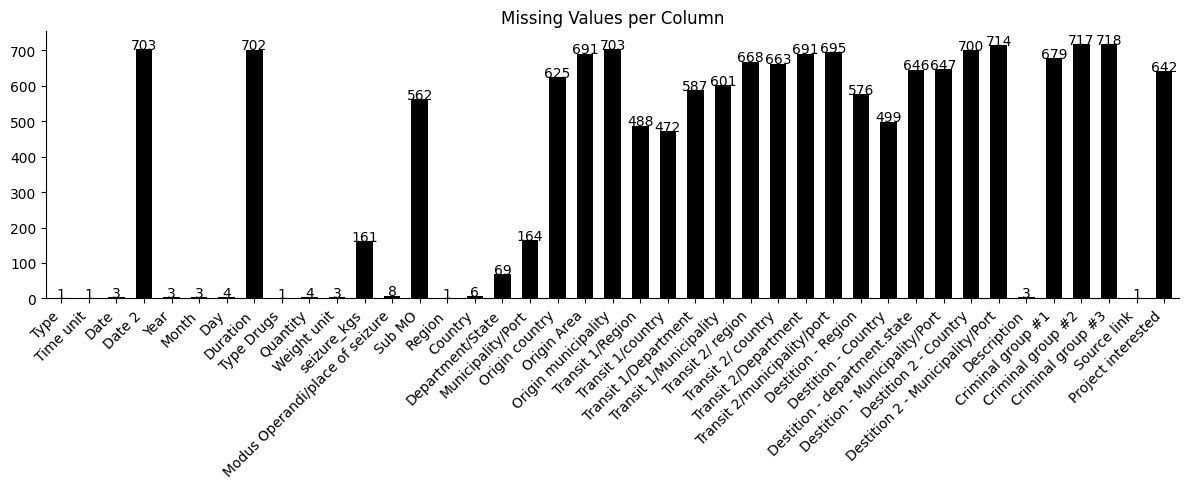

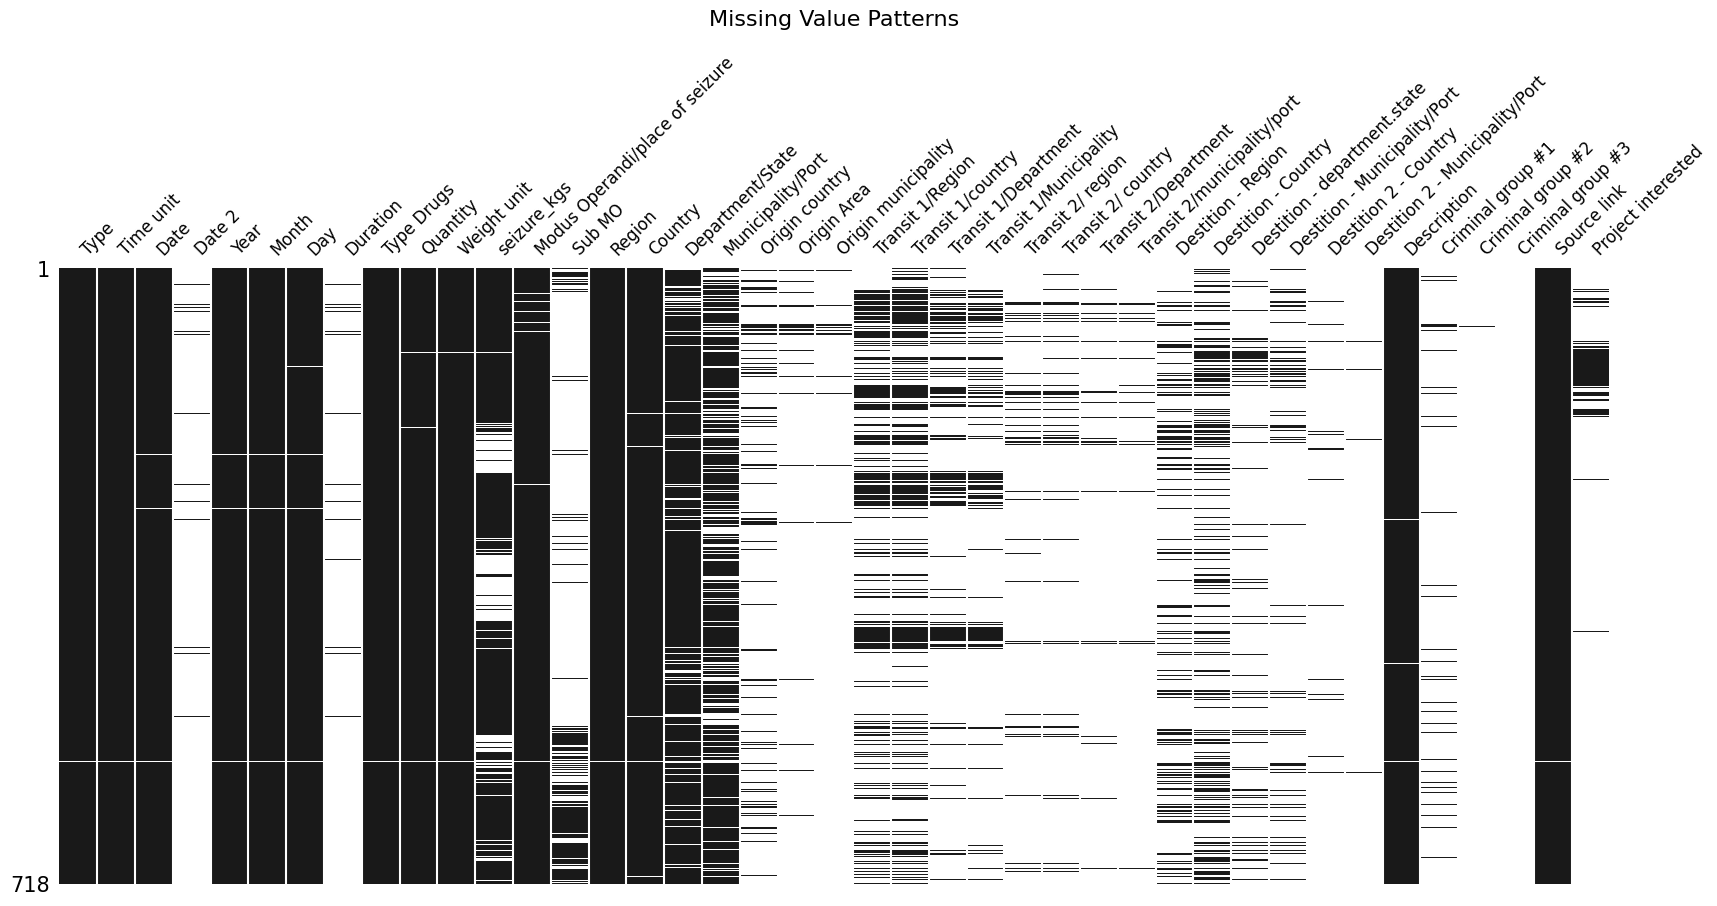

In [23]:

missing_values = df.isnull().sum()
print(f"Missing values per column:\n{missing_values}\n")

# Visualization 1: Bar Chart
plt.figure(figsize=(12, 5))
ax = missing_values.plot(kind='bar', color="#000000", width=0.6)
ax.grid(False)
for i in ax.patches:
    ax.text(i.get_x() + i.get_width()/2, i.get_height()+1, 
            f'{int(i.get_height())}', 
            ha='center', fontsize=10)
plt.xticks(rotation=45, ha='right')
sns.despine()
plt.title("Missing Values per Column")
plt.tight_layout()
plt.show()

# Visualization 2: Missingno Matrix
msno.matrix(
    df,
    figsize=(20, 8),
    color=(0.1, 0.1, 0.1),
    sparkline=False,
    fontsize=12,
    labels=True
)
plt.title("Missing Value Patterns", fontsize=16, pad=20)
plt.show()

##### Key Variables

###### Monthly seizures

/tmp/ipykernel_27718/965558087.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_27718/965558087.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_27718/965558087.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_27718/965558087.py:60: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
/tmp/ipykernel_27718/965558087.py:60: FutureWarning: DataFrame.applymap 

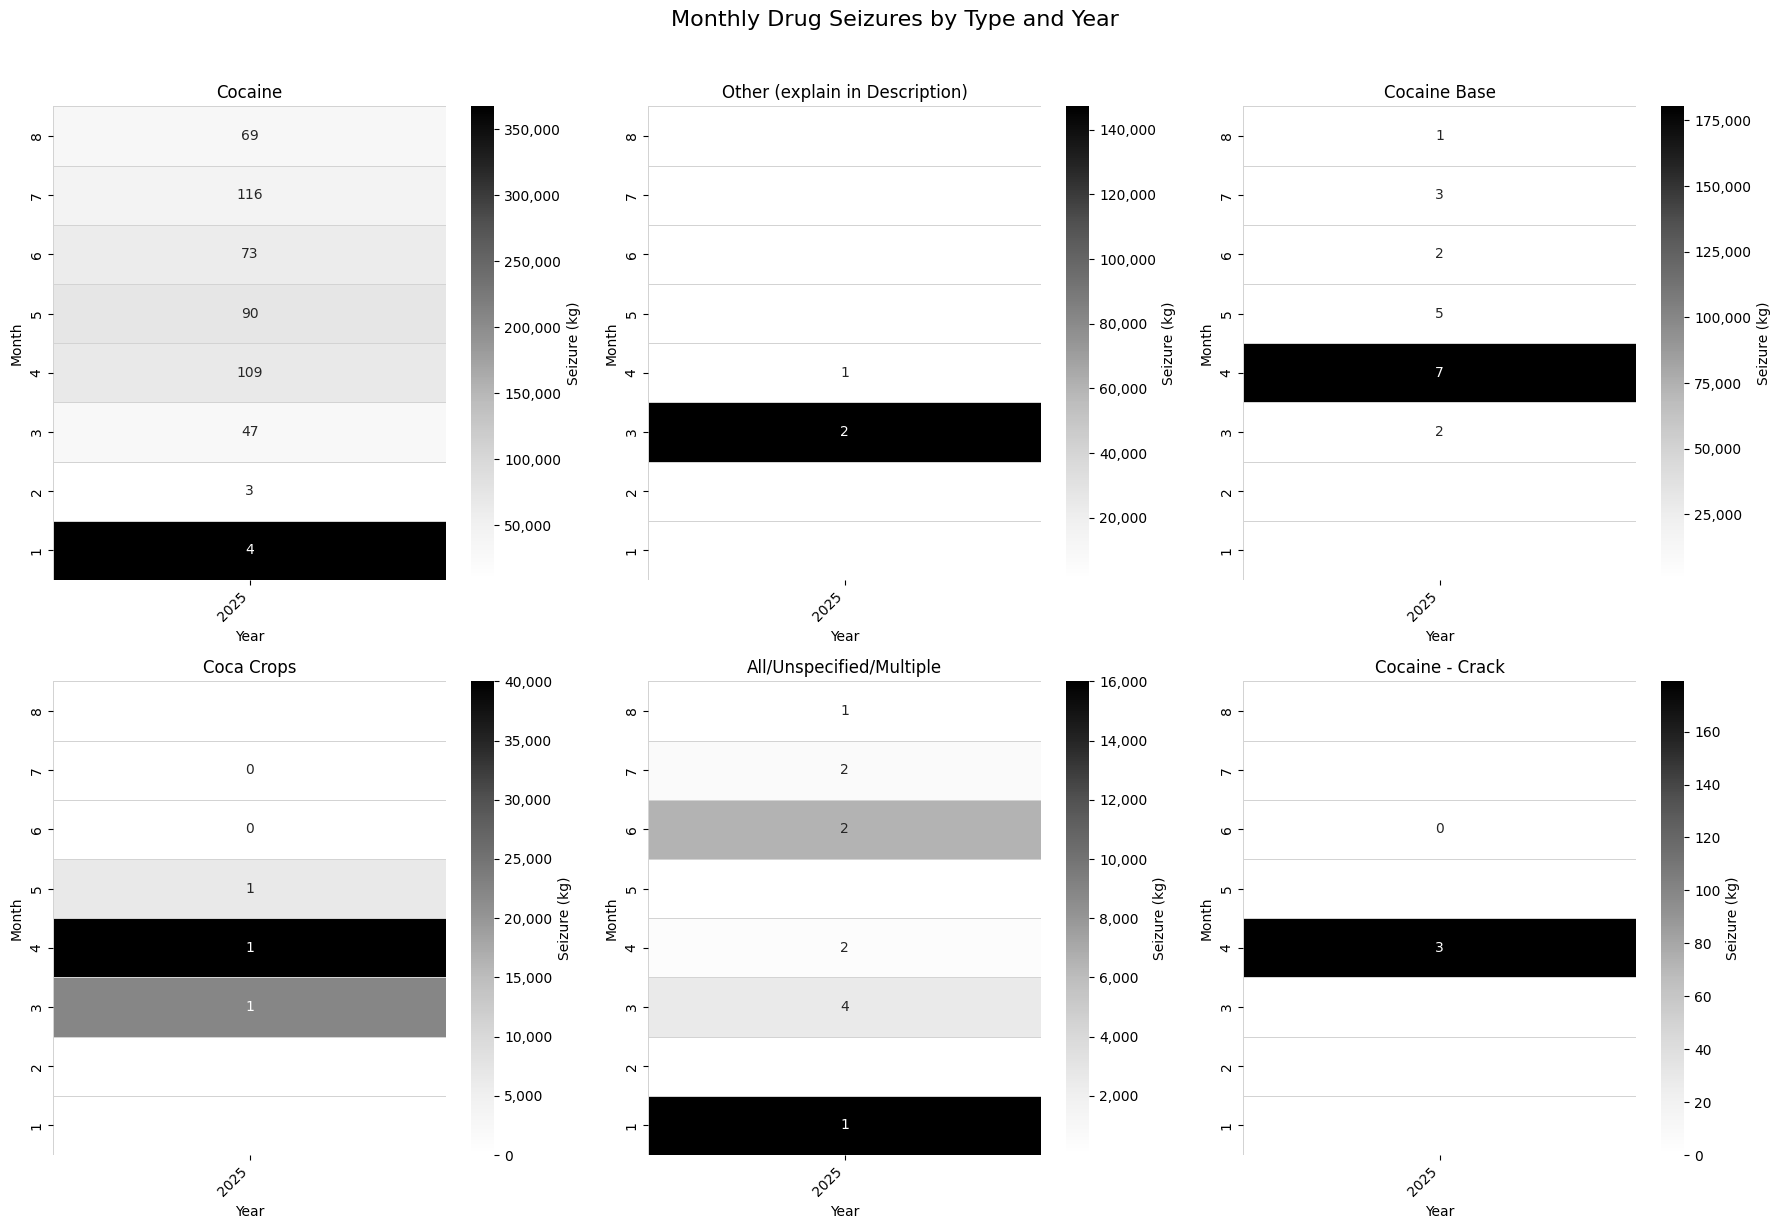

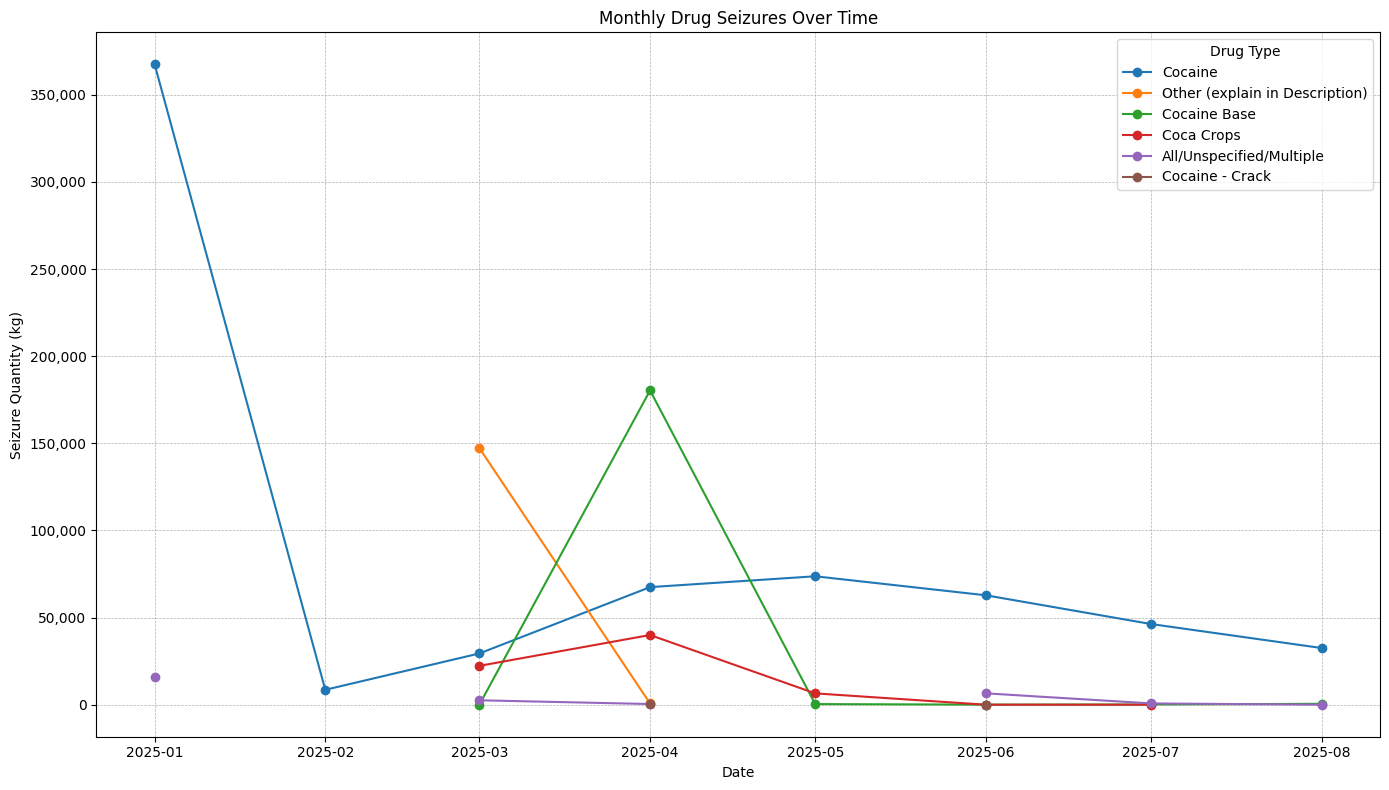

In [24]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import math
from matplotlib.ticker import FuncFormatter

# Clean the data - remove rows where Type Drugs is None/NaN
df = df.dropna(subset=['Type Drugs'])

# Convert and clean seizure data
df['seizure_kgs'] = pd.to_numeric(df['seizure_kgs'], errors='coerce')

# Create pivot tables grouped by Type Drugs
pivot_data = df.groupby(['Year', 'Month', 'Type Drugs']).agg(
    seizure_kg=('seizure_kgs', 'sum'),
    event_count=('seizure_kgs', 'count')
).unstack(level=[0, 2])  # Unstack both Year and Type Drugs

# Extract components
seizure_kg = pivot_data['seizure_kg']
event_counts = pivot_data['event_count']

# Fill NaN values with 0
seizure_kg_filled = seizure_kg.fillna(0)

# Get unique drug types for plotting
drug_types = df['Type Drugs'].unique()

# Calculate grid dimensions
n_drugs = len(drug_types)
n_cols = 3  # You can adjust this based on your preference
n_rows = math.ceil(n_drugs / n_cols)

# Create figure for grid layout
fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 6*n_rows))
fig.suptitle("Monthly Drug Seizures by Type and Year", y=1.02, fontsize=16)

# Flatten axes array for easy iteration
if n_rows > 1:
    axes = axes.flatten()
else:
    axes = [axes] if n_cols == 1 else axes

# Function to format numbers with commas
def format_with_commas(x, pos):
    return f"{x:,.0f}"

# Create formatter
comma_formatter = FuncFormatter(format_with_commas)

# Plot heatmap for each drug type in the grid
for i, drug in enumerate(drug_types):
    ax = axes[i]
    
    # Filter data for current drug type
    drug_kg = seizure_kg.xs(drug, level=1, axis=1)
    drug_counts = event_counts.xs(drug, level=1, axis=1)
    
    # Create annotation text with commas
    annot_text = drug_counts.sort_index(ascending=False).applymap(lambda x: f"{int(x):,}" if pd.notna(x) else "")
    
    heatmap = sns.heatmap(
        drug_kg.sort_index(ascending=False),
        cmap="Greys",
        annot=annot_text,
        fmt='',  # Empty string since we pre-formatted
        cbar_kws={'label': f'Seizure (kg)', 'format': comma_formatter},
        linewidths=0.5,
        linecolor='lightgray',
        ax=ax
    )
    
    # Format colorbar ticks with commas
    if heatmap.collections[0].colorbar is not None:
        heatmap.collections[0].colorbar.ax.yaxis.set_major_formatter(comma_formatter)
    
    ax.set_title(drug)
    ax.set_ylabel("Month")
    ax.set_xlabel("Year")
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

# Hide any empty subplots
for j in range(i+1, len(axes)):
    axes[j].axis('off')

plt.tight_layout()
plt.show()

# Line graph version with comma formatting
plt.figure(figsize=(14,8))

# Create date column for proper time series plotting
df['date'] = pd.to_datetime(df['Year'].astype(str) + '-' + df['Month'] + '-01')

# Group by date and drug type
line_data = df.groupby(['date', 'Type Drugs'])['seizure_kgs'].sum().unstack()

# Plot each drug type
for drug in drug_types:
    if drug in line_data.columns:
        plt.plot(line_data.index, line_data[drug], marker='o', label=drug)

plt.title("Monthly Drug Seizures Over Time")
plt.ylabel("Seizure Quantity (kg)")
plt.xlabel("Date")
plt.legend(title="Drug Type")
plt.grid(True, which='both', linestyle='--', linewidth=0.5)

# Format y-axis with commas
plt.gca().yaxis.set_major_formatter(FuncFormatter(format_with_commas))

plt.tight_layout()
plt.show()


###### Routes

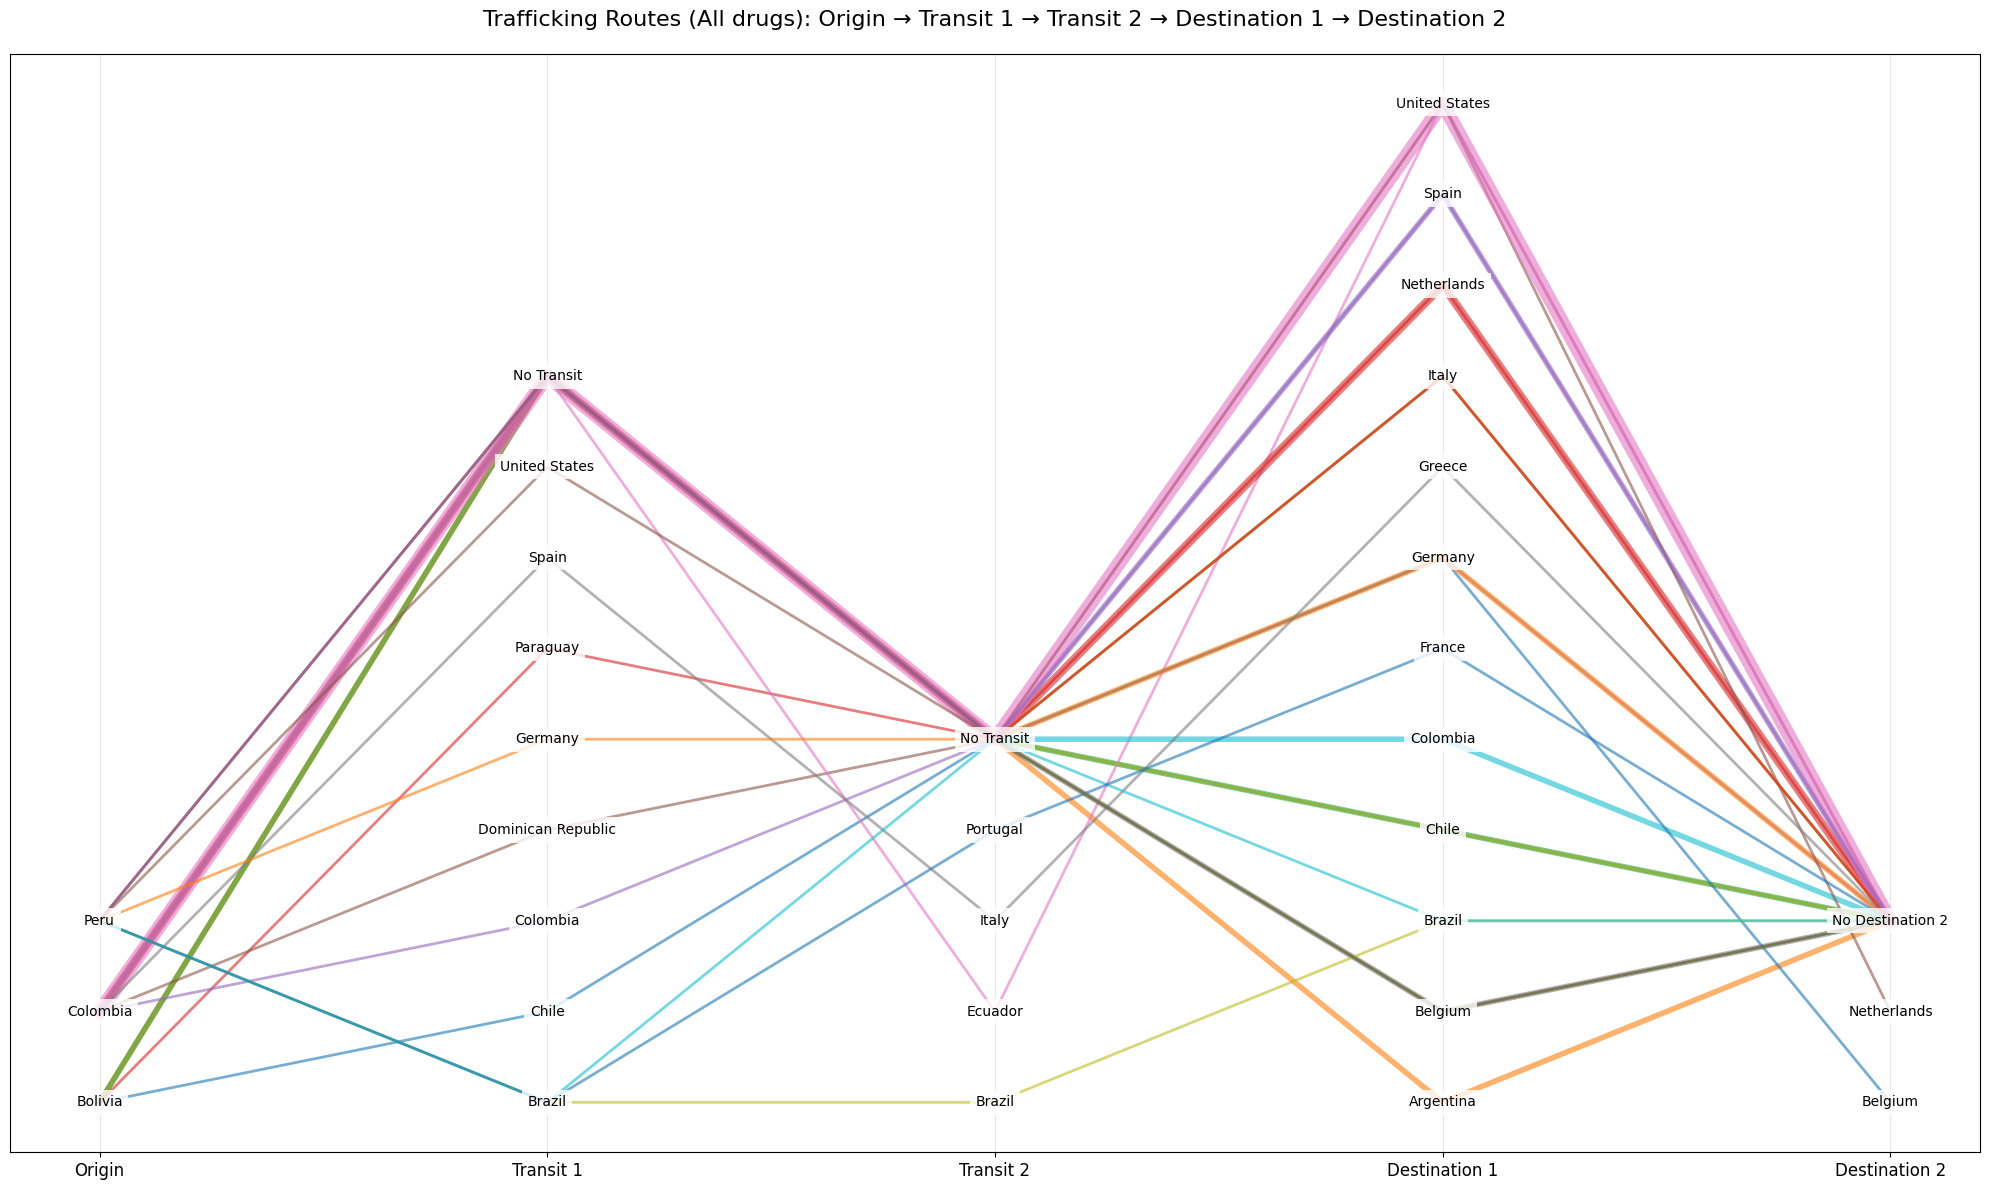

In [25]:
import matplotlib.pyplot as plt

def plot_parallel_sets(df): 
    # Define the column names
    columns = ['Origin country', 'Transit 1/country', 'Transit 2/ country',
               'Destition - Country', 'Destition 2 - Country']
    
    # Copy and fill missing values
    df = df[columns].copy()
    df[columns[1]] = df[columns[1]].fillna('No Transit')
    df[columns[2]] = df[columns[2]].fillna('No Transit')
    df[columns[4]] = df[columns[4]].fillna('No Destination 2')
    
    # Filter incomplete rows
    df.dropna(subset=[columns[0], columns[3]], inplace=True)
    if df.empty:
        print("Warning: No data with both origin and destination information")
        return
    
    # Count path frequencies
    path_counts = df.groupby(columns).size().reset_index(name='count')
    
    # Prepare the plot
    plt.figure(figsize=(20, 12))

    # Map each category to a y-position (starting at 1)
    categories = {}
    for col in columns:
        values = df[col].unique()
        sorted_vals = sorted([v for v in values if "No" not in v]) + sorted([v for v in values if "No" in v])
        categories[col] = {val: idx + 1 for idx, val in enumerate(sorted_vals)}
    
    # Plot each path
    for _, row in path_counts.iterrows():
        y_values = [categories[col][row[col]] for col in columns]
        plt.plot(range(len(columns)), y_values, linewidth=row['count'] * 2, alpha=0.6)

    # X-axis: step names
    plt.xticks(range(len(columns)), ['Origin', 'Transit 1', 'Transit 2', 'Destination 1', 'Destination 2'], fontsize=12)
    
    # Y-axis: remove default numbers
    plt.yticks([])
    
    # Add node labels
    for i, col in enumerate(columns):
        for val, y in categories[col].items():
            plt.text(i, y, val, ha='center', va='center',
                     bbox=dict(facecolor='white', alpha=0.8, edgecolor='none'), fontsize=10)
    
    # Final touches
    plt.title("Trafficking Routes (All drugs): Origin → Transit 1 → Transit 2 → Destination 1 → Destination 2", 
              fontsize=16, pad=20)
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

plot_parallel_sets(df)

In [ ]:
# import pandas as pd
# import matplotlib.pyplot as plt
# import numpy as np
# from datetime import datetime
# import seaborn as sns

# # Assuming your dataframe is called 'df'
# # First, let's prepare the data

# def create_origin_country_plots(df):
#     """
#     Create stacked area plots for each origin country showing monthly drug seizures by type
#     """
    
#     # Filter data to only include rows with origin country and seizure data
#     filtered_df = df.dropna(subset=['Origin country', 'seizure_kgs', 'Year-Month'])
    
#     # Get unique origin countries
#     origin_countries = filtered_df['Origin country'].unique()
    
#     # Get all unique drug types across all origin countries to create consistent color mapping
#     all_drug_types = filtered_df['Type Drugs'].unique()
#     print(f"Found {len(origin_countries)} origin countries: {origin_countries}")
#     print(f"Found {len(all_drug_types)} drug types: {all_drug_types}")
    
#     # Set up the plotting style and create consistent color mapping
#     plt.style.use('default')
#     colors = plt.cm.tab20(np.linspace(0, 1, len(all_drug_types)))  # Use tab20 colormap for more distinct colors
#     drug_color_map = dict(zip(all_drug_types, colors))
    
#     # Calculate number of subplots needed
#     n_countries = len(origin_countries)
#     n_cols = 2  # Two columns of plots
#     n_rows = (n_countries + n_cols - 1) // n_cols  # Ceiling division
    
#     # Create figure with subplots
#     fig, axes = plt.subplots(n_rows, n_cols, figsize=(15, 5 * n_rows))
    
#     # If only one row, make axes a 2D array for consistency
#     if n_rows == 1:
#         axes = axes.reshape(1, -1)
#     elif n_countries == 1:
#         axes = np.array([[axes]])
    
#     # Flatten axes for easier iteration
#     axes_flat = axes.flatten()
    
#     for i, country in enumerate(origin_countries):
#         ax = axes_flat[i]
        
#         # Filter data for this origin country
#         country_data = filtered_df[filtered_df['Origin country'] == country].copy()
        
#         # Group by Year-Month and Type Drugs, sum the seizures
#         monthly_data = country_data.groupby(['Year-Month', 'Type Drugs'])['seizure_kgs'].sum().reset_index()
        
#         # Pivot to get drug types as columns
#         pivot_data = monthly_data.pivot(index='Year-Month', columns='Type Drugs', values='seizure_kgs')
#         pivot_data = pivot_data.fillna(0)  # Fill NaN with 0
        
#         # Ensure all drug types are present (with 0 values if missing)
#         for drug_type in all_drug_types:
#             if drug_type not in pivot_data.columns:
#                 pivot_data[drug_type] = 0
        
#         # Reorder columns to match the order in all_drug_types for consistency
#         pivot_data = pivot_data[all_drug_types]
        
#         # Sort by date
#         pivot_data = pivot_data.sort_index()
        
#         if len(pivot_data) == 0:
#             ax.text(0.5, 0.5, f'No data for\n{country}', 
#                    horizontalalignment='center', verticalalignment='center',
#                    transform=ax.transAxes, fontsize=12)
#             ax.set_title(f'{country}')
#             continue
        
#         # Convert Period index to datetime for plotting
#         pivot_data.index = pivot_data.index.to_timestamp()
        
#         # Create stacked area plot with consistent colors
#         colors_for_plot = [drug_color_map[drug] for drug in pivot_data.columns]
#         ax.stackplot(pivot_data.index, 
#                     *[pivot_data[col] for col in pivot_data.columns],
#                     labels=pivot_data.columns,
#                     colors=colors_for_plot,
#                     alpha=0.7)
        
#         # Customize the plot
#         ax.set_title(f'{country}\nTotal Seizures by Drug Type', fontsize=12, fontweight='bold')
#         ax.set_xlabel('Date')
#         ax.set_ylabel('Quantity Seized (kg)')
        
#         # Format x-axis dates
#         ax.tick_params(axis='x', rotation=45)
        
#         # Add legend
#         ax.legend(loc='upper left', bbox_to_anchor=(1, 1), fontsize=8)
        
#         # Add grid for better readability
#         ax.grid(True, alpha=0.3)
        
#         # Format y-axis to show thousands separator
#         ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, p: f'{x:,.0f}'))
    
#     # Hide empty subplots
#     for j in range(i + 1, len(axes_flat)):
#         axes_flat[j].set_visible(False)
    
#     # Create a master legend outside the plots showing all drug types with consistent colors
#     handles = []
#     labels = []
#     for drug_type in all_drug_types:
#         handles.append(plt.Rectangle((0,0),1,1, facecolor=drug_color_map[drug_type], alpha=0.7))
#         labels.append(drug_type)
    
#     # Add master legend to the figure
#     fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1, 0.5), 
#                title='Drug Types', title_fontsize=12, fontsize=10)
    
#     # Adjust layout to accommodate legend
#     plt.tight_layout()
#     plt.subplots_adjust(right=0.85)  # Make room for the legend
#     plt.show()
    
#     # Also create a summary table
#     print("\nSummary by Origin Country:")
#     print("=" * 50)
    
#     summary_stats = []
#     for country in origin_countries:
#         country_data = filtered_df[filtered_df['Origin country'] == country]
#         total_seizures = country_data['seizure_kgs'].sum()
#         n_incidents = len(country_data)
#         drug_types = country_data['Type Drugs'].nunique()
#         date_range = f"{country_data['date'].min().strftime('%Y-%m')} to {country_data['date'].max().strftime('%Y-%m')}"
        
#         summary_stats.append({
#             'Origin Country': country,
#             'Total Seizures (kg)': f"{total_seizures:,.1f}",
#             'Number of Incidents': n_incidents,
#             'Drug Types': drug_types,
#             'Date Range': date_range
#         })
    
#     summary_df = pd.DataFrame(summary_stats)
#     print(summary_df.to_string(index=False))
    


# # Additional function to create individual plots if needed
# def create_individual_country_plot(df, country_name):
#     """
#     Create a detailed plot for a specific origin country with consistent colors
#     """
#     filtered_df = df.dropna(subset=['Origin country', 'seizure_kgs', 'Year-Month'])
    
#     # Get all unique drug types for consistent coloring
#     all_drug_types = filtered_df['Type Drugs'].unique()
#     colors = plt.cm.tab20(np.linspace(0, 1, len(all_drug_types)))
#     drug_color_map = dict(zip(all_drug_types, colors))
    
#     country_data = filtered_df[filtered_df['Origin country'] == country_name].copy()
    
#     if len(country_data) == 0:
#         print(f"No data found for {country_name}")
#         return None
    
#     # Group by Year-Month and Type Drugs
#     monthly_data = country_data.groupby(['Year-Month', 'Type Drugs'])['seizure_kgs'].sum().reset_index()
#     pivot_data = monthly_data.pivot(index='Year-Month', columns='Type Drugs', values='seizure_kgs')
#     pivot_data = pivot_data.fillna(0)
    
#     # Ensure all drug types are present (with 0 values if missing)
#     for drug_type in all_drug_types:
#         if drug_type not in pivot_data.columns:
#             pivot_data[drug_type] = 0
    
#     # Reorder columns to match the order in all_drug_types for consistency
#     pivot_data = pivot_data[all_drug_types]
#     pivot_data = pivot_data.sort_index()
#     pivot_data.index = pivot_data.index.to_timestamp()
    
#     # Create larger individual plot
#     plt.figure(figsize=(12, 8))
#     colors_for_plot = [drug_color_map[drug] for drug in pivot_data.columns]
#     plt.stackplot(pivot_data.index, 
#                  *[pivot_data[col] for col in pivot_data.columns],
#                  labels=pivot_data.columns,
#                  colors=colors_for_plot,
#                  alpha=0.7)
    
#     plt.title(f'Drug Seizures from {country_name}\nMonthly Quantities by Type', 
#               fontsize=16, fontweight='bold')
#     plt.xlabel('Date', fontsize=12)
#     plt.ylabel('Quantity Seized (kg)', fontsize=12)
#     plt.legend(loc='center left', bbox_to_anchor=(1, 0.5))
#     plt.grid(True, alpha=0.3)
#     plt.xticks(rotation=45)
#     plt.tight_layout()
#     plt.show()
    
#     return pivot_data

# # Usage:
# create_origin_country_plots(df)
# # 
# # For individual country plots:
# # create_individual_country_plot(df, 'Colombia')  # Replace with actual country name

###### Modus operandi

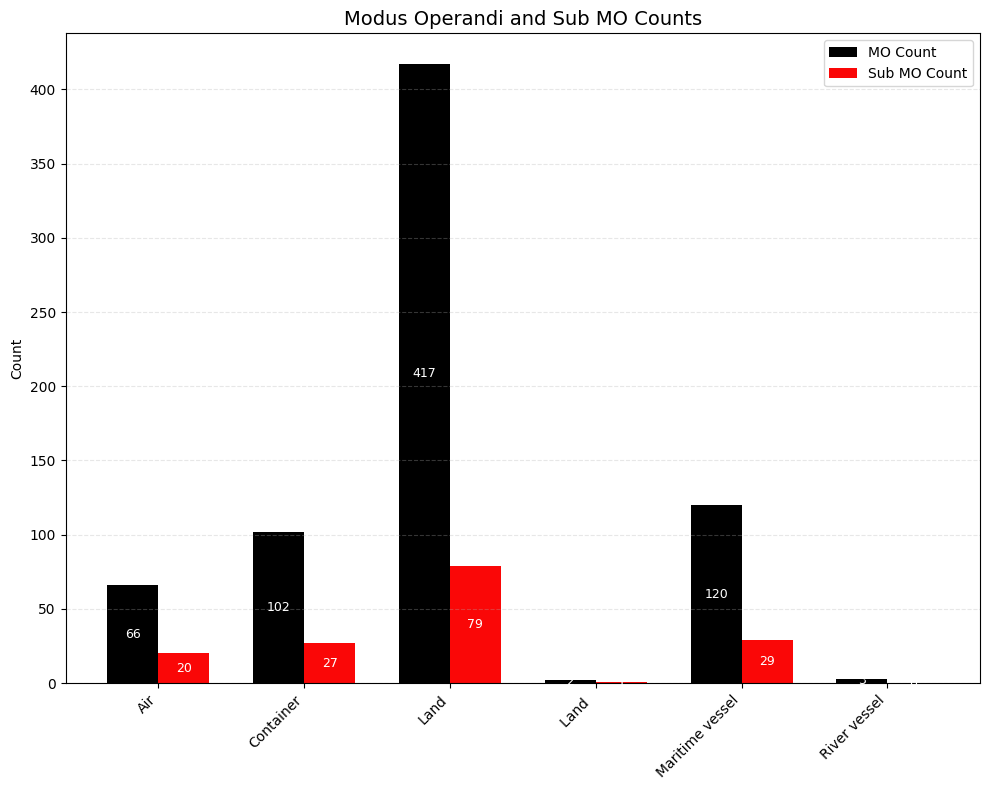

In [26]:
import numpy as np

# Group counts
mo = df['Modus Operandi/place of seizure'].value_counts().sort_index()
sub_mo = df.groupby('Modus Operandi/place of seizure')['Sub MO'].count().reindex(mo.index)

# Plot
labels = mo.index
x = np.arange(len(labels))
w = 0.35

fig, ax = plt.subplots(figsize=(10, 8))
b1 = ax.bar(x - w/2, mo, w, label='MO Count', color="#000000")
b2 = ax.bar(x + w/2, sub_mo, w, label='Sub MO Count', color="#FA0707")

# Label bars
for bars in [b1, b2]:
    for bar in bars:
        ax.text(bar.get_x() + bar.get_width()/2, bar.get_height()/2,
                str(int(bar.get_height())), ha='center', va='center', color='white', fontsize=9)

# Style
ax.set_xticks(x)
ax.set_xticklabels(labels, rotation=45, ha='right')
ax.set_title('Modus Operandi and Sub MO Counts', fontsize=14)
ax.legend()
ax.set_ylabel('Count')
plt.tight_layout()
plt.grid(axis='y', linestyle='--', alpha=0.3)
plt.show()



## Validation

#### General

##### Column names

In [36]:
# Dictionary mapping old column names to new names
custom_column_names = {
    "Type": "event_type",
    "Time unit": "time_unit",
    "Date": "date_1",
    "Date 2": "date_2",
    "Year": "year",
    "Month": "month",
    "Day": "day",
    "Duration": "duration",
    "Type Drugs": "drug_type",
    "Quantity": "quantity",
    "Weight unit": "weight_unit",
    "seizure_kgs": "seizure_kg",
    "Modus Operandi/place of seizure": "modus_operandi/place_seizure",
    "Sub MO": "sub_modus_operandi",
    "Region": "region",
    "Country": "country",
    "Department/State": "department/state",
    "Municipality/Port": "municipality/port",
    "Origin country": "origin_country",
    "Origin Area": "origin_area",
    "Origin municipality": "origin_municipality",
    "Transit 1/Region": "transit_1_region",
    "Transit 1/country": "transit_1_country",
    "Transit 1/Department": "transit_1_department/state",
    "Transit 1/Municipality": "transit_1_municipality/port",
    "Transit 2/ region": "transit_2_region",
    "Transit 2/ country": "transit_2_country",
    "Transit 2/Department": "transit_2_department/state",
    "Transit 2/municipality/port": "transit_2_municipality/port",
    "Destition - Region": "destination_1_region",
    "Destition - Country": "destination_1_country",
    "Destition - department.state": "destination_1_department/state",
    "Destition - Municipality/Port": "destination_1_municipality/port",
    "Destition 2 - Country": "destination_2_country",
    "Destition 2 - Municipality/Port": "destination_2_municipality/port",
    "Description": "description",
    "Criminal group #1": "criminal_group_1",
    "Criminal group #2": "criminal_group_2",
    "Criminal group #3": "criminal_group_3",
    "Source link": "source_link",
    "Project interested": "project_interest"
}

# Apply renaming
df.rename(columns=custom_column_names, inplace=True)


In [38]:
# Get the current headers to map them
current_headers = sheet.values().get(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range=f"{RANGE_NAME.split('!')[0]}!1:1",  # Get just header row
    majorDimension="ROWS"
).execute().get('values', [[]])[0]

# Create new headers list by mapping old names to new names
new_headers = [custom_column_names.get(header, header) for header in current_headers]

# Update just the header row
sheet.values().update(
    spreadsheetId=ORIGINAL_SPREADSHEET_ID,
    range=f"{RANGE_NAME.split('!')[0]}!1:1",  # Update just header row
    valueInputOption='RAW',
    body={'values': [new_headers]}
).execute()

print("Column names updated")

Column names updated


##### Dropdowns

###### Options

In [39]:
# Indentify Existing Dropdowns
 
def get_sheet_dropdowns(spreadsheet_id, sheet_name, creds):
    service = build('sheets', 'v4', credentials=creds)
    sheet_metadata = service.spreadsheets().get(
        spreadsheetId=spreadsheet_id,
        ranges=[sheet_name],
        includeGridData=True
    ).execute()

    dropdowns_by_column = {}

    for sheet in sheet_metadata['sheets']:
        if sheet['properties']['title'] != sheet_name:
            continue

        col_dropdowns = {}
        rows = sheet['data'][0]['rowData']
        header_row = rows[0]['values']
        col_names = [cell.get('formattedValue', f"Column_{i}") for i, cell in enumerate(header_row)]

        for col_idx, col_name in enumerate(col_names):
            dropdowns_in_col = set()
            for row in rows[1:]:  # Skip header
                cell = row['values'][col_idx]
                if 'dataValidation' in cell:
                    dv = cell['dataValidation']
                    if dv['condition']['type'] == 'ONE_OF_LIST':
                        values = [v['userEnteredValue'] for v in dv['condition']['values']]
                        dropdowns_in_col.update(values)
            if dropdowns_in_col:
                col_dropdowns[col_name] = list(dropdowns_in_col)

        dropdowns_by_column.update(col_dropdowns)

    return dropdowns_by_column

dropdown_options = get_sheet_dropdowns(ORIGINAL_SPREADSHEET_ID, 'db-test', creds)

# Print results
for col, options in dropdown_options.items():
    print(f"🔽 {col}: {options}")


🔽 event_type: ['Total Crop Cultivation Estimate', 'Other (explain in Description)', 'Price', 'Total Production Estimate', 'Seizure', 'Crop Eradication']
🔽 time_unit: ['Individual', 'Multi-Month', 'Month', 'Other (explain in Description)', 'Multi-Year', 'Year']
🔽 drug_type: ['All/Unspecified/Multiple', 'Cocaine - Crack', 'Other (explain in Description)', 'Cocaine Base', 'Cocaine', 'Coca Crops']
🔽 weight_unit: ['Plant', 'Pounds (lbs)', 'Hectare', 'USD', 'Kilogram', 'Pounds (£)', 'Other currency (say which in Description)', 'Other (explain in Description)', 'Percent', 'Package', 'Euro']
🔽 modus_operandi/place_seizure: ['Land', 'Air', 'River vessel', 'Maritime vessel', 'Container']
🔽 region: ['Africa', 'Europe', 'North America', 'Global', 'Oceania', 'Asia', 'Central America', 'South America', 'Caribbean']
🔽 origin_country: ['Colombia', '""', 'Bolivia', 'Peru']
🔽 transit_1_region: ['Africa', 'Europe', 'North America', 'Global', 'Oceania', 'Asia', 'Australia', 'Central America', 'South Ameri

In [40]:
dropdown_options = {
    "event_type": [
        'Crop Eradication', 'Total Crop Cultivation Estimate', 'Price',
        'Total Production Estimate', 'Other (explain in Description)', 'Seizure'
    ],
    "time_unit": [
        'Multi-Year', 'Multi-Month', 'Month', 'Other (explain in Description)',
        'Individual', 'Year'
    ],
    "drug_type": [
        'Coca Crops', 'All/Unspecified/Multiple', 'Cocaine',
        'Other (explain in Description)', 'Cocaine - Crack', 'Cocaine Base'
    ],
    "weight_unit": [
        'Percent', 'Other currency (say which in Description)', 'Hectare',
        'Euro', 'Plant', 'USD', 'Other (explain in Description)',
        'Pounds (lbs)', 'Kilogram', 'Pounds (£)', 'Package'
    ],
    "modus_operandi/place_seizure": [
        'River vessel', 'Container', 'Maritime vessel', 'Land', 'Air'
    ],
    "region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "origin_country": ['Peru', 'Bolivia', 'Unknown', 'Colombia'], # '""' REPLACED with 'Unknown'
    
    "transit_1_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "transit_2_region": [
        'Global', 'Central America', 'Asia', 'Europe', 'Oceania',
        'South America', 'Caribbean', 'North America', 'Africa'
    ],
    "destination_1_region": [
        'Central America', 'Asia', 'Europe', 'South America',
        'Caribbean', 'North America', 'Australia', 'Africa'
    ],
    
    "project_interest": ['Cocaine Pipeline', 'El PACCTO 2.0', 'MAD', 'Dutch']
}

###### Places

In [41]:
# Official list of places URL 
places_url = "https://github.com/FelipeVillota/resources/raw/main/list-of-places-ic.xlsx"

# Load the Excel file (defaulting to first sheet, or specify sheet_name if needed)
places_df = pd.read_excel(places_url)

# Preview the columns to identify the correct one for country list
print(places_df.columns)

print("\nColumns and their unique value counts:")
for col in places_df.columns:
    unique_count = places_df[col].nunique()
    print(f"{col}: {unique_count} unique values")

Index(['municipality', 'department/state', 'country'], dtype='object')

Columns and their unique value counts:
municipality: 129008 unique values
department/state: 3355 unique values
country: 192 unique values


In [42]:
official_countries = (
    places_df["country"]  
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_municipalities = (
    places_df["municipality"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

official_departments_states = (
    places_df["department/state"] 
    .dropna()
    .astype(str)
    .str.strip()
    .unique()
    .tolist()
)

In [43]:
country_related_keys = [
    "country",
    "origin_country",
    "transit_1_country",
    "transit_2_country",
    "destination_1_country",
    "destination_2_country"
]

# municipality_related_keys = [
#     "municipality/port",
#     "origin_municipality",
#     "transit_1_municipality/port",
#     "transit_2_municipality/port",
#     "destination_1_municipality/port",
#     "destination_2_municipality/port"
# ]

# department_state_related_keys = [
#     "department/state",
#     # "origin_area",  # assuming this is equivalent
#     "transit_1_department/state",
#     "transit_2_department/state",
#     "destination_1_department/state"
# ]

# Process country-related keys 
for key in country_related_keys:
    dropdown_options[key] = {
        "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
        "official_list": sorted(official_countries)
    }

# # to municipalities
# for key in municipality_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_municipalities)
#     }

# # to departments/states
# for key in department_state_related_keys:
#     dropdown_options[key] = {
#         "from_data": sorted(df[key].dropna().astype(str).str.strip().unique().tolist()) if key in df.columns else [],
#         "official_list": sorted(official_departments_states)
#     }


In [44]:
dropdown_options["origin_country"]

{'from_data': ['Bolivia', 'Colombia', 'Peru'],
 'official_list': ['Afghanistan',
  'Albania',
  'Algeria',
  'Andorra',
  'Angola',
  'Antigua And Barbuda',
  'Argentina',
  'Armenia',
  'Australia',
  'Austria',
  'Azerbaijan',
  'Bahamas The',
  'Bahrain',
  'Bangladesh',
  'Barbados',
  'Belarus',
  'Belgium',
  'Belize',
  'Benin',
  'Bhutan',
  'Bolivia',
  'Bosnia and Herzegovina',
  'Botswana',
  'Brazil',
  'Brunei',
  'Bulgaria',
  'Burkina Faso',
  'Burundi',
  'Cambodia',
  'Cameroon',
  'Canada',
  'Cape Verde',
  'Central African Republic',
  'Chad',
  'Chile',
  'China',
  'Colombia',
  'Comoros',
  'Congo',
  'Congo The Democratic Republic Of The',
  'Costa Rica',
  "Cote D'Ivoire (Ivory Coast)",
  'Croatia (Hrvatska)',
  'Cuba',
  'Cyprus',
  'Czech Republic',
  'Denmark',
  'Djibouti',
  'Dominica',
  'Dominican Republic',
  'East Timor',
  'Ecuador',
  'Egypt',
  'El Salvador',
  'Equatorial Guinea',
  'Eritrea',
  'Estonia',
  'Ethiopia',
  'Fiji Islands',
  'Finland

In [45]:
def apply_dropdowns_to_sheet(sheet_service, spreadsheet_id, sheet_name, dropdown_options, max_rows=150000):
    
    # Get the sheet ID by matching the sheet name
    spreadsheet = sheet_service.spreadsheets().get(spreadsheetId=spreadsheet_id).execute()
    sheet_id = None
    for sheet in spreadsheet['sheets']:
        if sheet['properties']['title'] == sheet_name:
            sheet_id = sheet['properties']['sheetId']
            break
    if sheet_id is None:
        print(f"❌ Sheet name '{sheet_name}' not found.")
        return

    # Fetch header row (assumes headers are in row 1)
    result = sheet_service.spreadsheets().values().get(
        spreadsheetId=spreadsheet_id,
        range=f"{sheet_name}!1:1"
    ).execute()
    headers = result.get('values', [])[0]

    requests = []  # Will store all the API requests we need to make

    # Handle both direct list options and dictionary format with "official_list"
    for col_name, options in dropdown_options.items():
        if col_name not in headers:
            continue

        col_index = headers.index(col_name)
        values = (
            options.get("official_list", []) if isinstance(options, dict)
            else options
        )
        values = values[:500]  # Apparently it can only handle this, or else it breaks the API

        if not values:
            continue

    # Create data validation rule for dropdown
        validation_rule = {
            "condition": {
                "type": "ONE_OF_LIST",
                "values": [{"userEnteredValue": str(v)} for v in values]
            },
            "strict": True,
            "showCustomUi": True
        }

    # Add request for this column's dropdown
        requests.append({
            "setDataValidation": {
                "range": {
                    "sheetId": sheet_id,
                    "startRowIndex": 1,
                    "endRowIndex": max_rows,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "rule": validation_rule
            }
        })

    # Execute all requests if we have any
    if requests:
        try:
            sheet_service.spreadsheets().batchUpdate(
                spreadsheetId=spreadsheet_id,
                body={"requests": requests}
            ).execute()
            print(f"✅ Applied dropdown formatting to {len(requests)} columns.")
        except Exception as e:
            print(f"❌ Error applying dropdowns: {e}")
    else:
        print("⚠️ No matching columns found in the sheet.")
        
apply_dropdowns_to_sheet(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,  
    sheet_name=RANGE_NAME,                 
    dropdown_options=dropdown_options, 
    max_rows=150000                  
)


✅ Applied dropdown formatting to 16 columns.


### Theme mapping

In [58]:
category_mapping = {
        "Event Metadata": [
            "event_type", "time_unit", "date_1", "date_2", "year", "month", "day",
            "duration", "description", "source_link", "project_interest"
        ],
        "Drugs & Quantities": [
            "drug_type", "quantity", "weight_unit", "seizure_kg"
        ],
        "Modus Operandi": [
            "modus_operandi/place_seizure", "sub_modus_operandi"
        ],
        "Seizure Location": [
            "region", "country", "department/state", "municipality/port"
        ],
        "Origin": [
            "origin_country", "origin_area", "origin_municipality"
        ],
        "Transit": [
            "transit_1_region", "transit_1_country", "transit_1_department/state", "transit_1_municipality/port",
            "transit_2_region", "transit_2_country", "transit_2_department/state", "transit_2_municipality/port"
        ],
        "Destination": [
            "destination_1_region", "destination_1_country", "destination_1_department/state",
            "destination_1_municipality/port", "destination_2_country", "destination_2_municipality/port"
        ],
        "Criminal Actors": [
            "criminal_group_1", "criminal_group_2", "criminal_group_3"
        ]
    }


In [59]:
def print_full_mapping(df):
    """Print complete column mapping with categories and indices."""

    # Create column index mapping
    column_indices = {col: idx for idx, col in enumerate(df.columns)}

    # Print header
    print("="*80)
    print("COMPLETE COLUMN MAPPING WITH CATEGORIES AND INDICES")
    print("="*80)
    print(f"Total columns in DataFrame: {len(df.columns)}")
    print(f"Total categories: {len(category_mapping)}\n")

    # Print each category with its columns
    for category, columns in category_mapping.items():
        print(f"\n🔷 {category.upper()} (Columns: {len(columns)})")
        print("-"*60)
        
        for col in columns:
            idx = column_indices.get(col, "MISSING")
            non_null = df[col].count() if col in df.columns else 0
            dtype = df[col].dtype if col in df.columns else "N/A"
            
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print any unmapped columns
    mapped_cols = set().union(*category_mapping.values())
    unmapped_cols = set(df.columns) - mapped_cols
    
    if unmapped_cols:
        print("\n⚠️ UNMAPPED COLUMNS:")
        print("-"*60)
        for col in unmapped_cols:
            idx = column_indices[col]
            non_null = df[col].count()
            dtype = df[col].dtype
            print(f"  {idx:2d} | {col:35} | {str(dtype):10} | Non-null: {non_null:4d}")

    # Print verification summary
    print("\n" + "="*80)
    print("VERIFICATION SUMMARY:")
    print(f"- Mapped columns: {len(mapped_cols & set(df.columns))}")
    print(f"- Unmapped columns: {len(unmapped_cols)}")
    print(f"- Missing expected columns: {len(set(mapped_cols) - set(df.columns))}")
    print("="*80)

# Example usage
if __name__ == "__main__":
    # Assuming your DataFrame is named 'df'
    print_full_mapping(df)

COMPLETE COLUMN MAPPING WITH CATEGORIES AND INDICES
Total columns in DataFrame: 42
Total categories: 8


🔷 EVENT METADATA (Columns: 11)
------------------------------------------------------------
   0 | event_type                          | object     | Non-null:  654
   1 | time_unit                           | object     | Non-null:  654
   2 | date_1                              | object     | Non-null:  652
   3 | date_2                              | object     | Non-null:   14
   4 | year                                | object     | Non-null:  652
   5 | month                               | object     | Non-null:  652
   6 | day                                 | object     | Non-null:  651
   7 | duration                            | object     | Non-null:   15
  35 | description                         | object     | Non-null:  652
  39 | source_link                         | object     | Non-null:  654
  40 | project_interest                    | object     | Non-null:   76


#### Event Metadata

Variables: _Type, Time unit, Date, Date 2, Year, Month, Day, Duration, Description, Source link, Project interested_

In [61]:
print(category_mapping["Event Metadata"])

['event_type', 'time_unit', 'date_1', 'date_2', 'year', 'month', 'day', 'duration', 'description', 'source_link', 'project_interest']


In [62]:
def event_metadata_report(df):
    
    # Focus only on event metadata columns
    EVENT_COLS = category_mapping["Event Metadata"]
    report = []
    issues = {}
    total_problems = 0

    # Helper functions
    def to_excel_rows(indices):
        return [i+2 for i in indices]

    def register_issue(name, problematic_df, description):
        nonlocal total_problems
        issue_rows = problematic_df.index.tolist()
        issues[name] = {
            'indices': issue_rows,
            'excel_rows': to_excel_rows(issue_rows),
            'sample': problematic_df,
            'description': description
        }
        count = len(issue_rows)
        total_problems += count
        return count

    # Validation 1: Check for missing critical columns
    missing_cols = [col for col in EVENT_COLS if col not in df.columns]
    if missing_cols:
        report.append(("❌ Missing Columns", f"{len(missing_cols)} key columns missing: {', '.join(missing_cols)}"))
        total_problems += len(missing_cols)

    # Validation 2: Date validations
    date_issues = []
    if 'date_1' in df.columns:
        empty_dates = df[df['date_1'].isna()]
        if not empty_dates.empty:
            count = register_issue(
                'empty_primary_dates',
                empty_dates,
                "Rows missing primary date (date_1)"
            )
            date_issues.append(f"{count} empty date_1 values")

    # Validation 3: Duration consistency
    if all(col in df.columns for col in ['date_2', 'duration']):
        invalid_duration = df[
            (df['date_2'].isna()) & 
            (df['duration'].notna())
        ]
        if not invalid_duration.empty:
            count = register_issue(
                'duration_without_end_date',
                invalid_duration[['date_1', 'date_2', 'duration']],
                "Has duration but no end date (date_2)"
            )
            date_issues.append(f"{count} duration/date_2 mismatches")

    if date_issues:
        report.append(("⚠️ Date Issues", "; ".join(date_issues)))

    # Validation 4: Time unit logic
    if 'time_unit' in df.columns:
        time_unit_issues = []
        
        # Case 1: Multi-day events marked as individual
        if 'date_2' in df.columns:
            invalid_time = df[
                (df['date_2'].notna()) & 
                (df['time_unit'] == 'Individual')
            ]
            if not invalid_time.empty:
                count = register_issue(
                    'multiday_individual_events',
                    invalid_time[['time_unit', 'date_1', 'date_2']],
                    "Multi-day event marked as 'Individual' time unit"
                )
                time_unit_issues.append(f"{count} multi-day as Individual")

        # Case 2: Individual events with duration
        if 'duration' in df.columns:
            invalid_duration = df[
                (df['time_unit'] == 'Individual') & 
                (df['duration'].notna())
            ]
            if not invalid_duration.empty:
                count = register_issue(
                    'individual_with_duration',
                    invalid_duration[['time_unit', 'duration']],
                    "Individual events shouldn't have duration"
                )
                time_unit_issues.append(f"{count} Individual with duration")

        if time_unit_issues:
            report.append(("⚠️ Time Unit Issues", "; ".join(time_unit_issues)))

    # Generate the report
    print("="*80)
    print(f"EVENT METADATA VALIDATION REPORT".center(80))
    print(f"Total Issues Found: {total_problems}".center(80))
    print("="*80)
    
    # Summary Section
    print("\n🔍 SUMMARY CHECKS:")
    for check, message in report:
        print(f"• {check:<20} {message}")
    
    # Detailed Findings
    if issues:
        print("\n" + "="*80)
        print("🔴 DETAILED ISSUES".center(80))
        print("="*80)
        
        for issue_name, data in issues.items():
            print(f"\n❗ {data['description'].upper()}")
            print(f"   Rows affected: {len(data['indices'])} (Spreadsheet rows: {data['excel_rows']})")
            print("\nSample Data:")
            print(data['sample'].head(3).to_string(index=False))
            print("-"*60)
    
    print("\n" + "="*80)
    print("ℹ️ Note: Spreadsheet rows account for header (pandas index + 2)".center(80))
    print("="*80)
    
    return {
        'report': report,
        'issues': issues,
        'total_problems': total_problems
    }

# Usage
validation_results = event_metadata_report(df)

                        EVENT METADATA VALIDATION REPORT                        
                             Total Issues Found: 7                              

🔍 SUMMARY CHECKS:
• ⚠️ Date Issues       2 empty date_1 values; 1 duration/date_2 mismatches
• ⚠️ Time Unit Issues  2 multi-day as Individual; 2 Individual with duration

                               🔴 DETAILED ISSUES                                

❗ ROWS MISSING PRIMARY DATE (DATE_1)
   Rows affected: 2 (Spreadsheet rows: [219, 282])

Sample Data:
event_type  time_unit date_1 date_2 year month  day duration drug_type quantity weight_unit  seizure_kg modus_operandi/place_seizure sub_modus_operandi        region  country department/state municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country transit_2_department/state transit_2_municipality/port destination_1_region destination_1_country de

              EVENT METADATA REPORT (Problematic Rows in Total: 5)              

SUMMARY:
❌ Empty Dates                  2 rows at spreadsheet rows: [219, 282]
❌ Duration Conflict            1 rows at spreadsheet rows: [341]
❌ Time Unit Conflict           2 rows at spreadsheet rows: [44, 48]

                                PROBLEMATIC ROWS                                

🔴 EMPTY DATES (2 ROWS)
Spreadsheet Rows: [219, 282]

Problematic Data:
event_type  time_unit date_1 date_2 year month  day duration drug_type quantity weight_unit  seizure_kg modus_operandi/place_seizure sub_modus_operandi        region  country department/state municipality/port origin_country origin_area origin_municipality transit_1_region transit_1_country transit_1_department/state transit_1_municipality/port transit_2_region transit_2_country transit_2_department/state transit_2_municipality/port destination_1_region destination_1_country destination_1_department/state destination_1_municipality/port destinati

🔄 Fetching column mapping...
🔍 Retrieved mapping keys: dict_keys(['event_type', 'time_unit', 'date_1', 'date_2', 'year', 'month', 'day', 'duration', 'drug_type', 'quantity', 'weight_unit', 'seizure_kg', 'modus_operandi/place_seizure', 'sub_modus_operandi', 'region', 'country', 'department/state', 'municipality/port', 'origin_country', 'origin_area', 'origin_municipality', 'transit_1_region', 'transit_1_country', 'transit_1_department/state', 'transit_1_municipality/port', 'transit_2_region', 'transit_2_country', 'transit_2_department/state', 'transit_2_municipality/port', 'destination_1_region', 'destination_1_country', 'destination_1_department/state', 'destination_1_municipality/port', 'destination_2_country', 'destination_2_municipality/port', 'description', 'criminal_group_1', 'criminal_group_2', 'criminal_group_3', 'source_link', 'project_interest'])
🔴 Mapping missing 'forward' key. Full mapping structure:
{'event_type': 0, 'time_unit': 1, 'date_1': 2, 'date_2': 3, 'year': 4, 'mon

#### Drugs & Quantities

Variables: _Type Drugs, Quantity, Weight unit, seizure_kgs_

In [91]:
def drugs_and_quantities_report(df):
    report = []
    issues = {}
    total_problems = 0

    def to_excel_rows(indices):
        return [i + 2 for i in indices]  # For spreadsheet row reference

    # Validation 1: Missing or Unknown Types of Drugs
    if 'drug_type' not in df.columns:
        report.append(("❌ Missing Column", "'drug_type' column not found"))
        total_problems += 1  # Count missing column as a problem
    else:
        invalid_drugs = df[df['drug_type'].isna() | df['drug_type'].str.lower().isin(['', 'unknown', 'n/a', 'na'])]
        if not invalid_drugs.empty:
            issue_rows = invalid_drugs.index.tolist()
            excel_rows = to_excel_rows(issue_rows)
            issues['invalid_drug_type'] = {
                'indices': issue_rows,
                'excel_rows': excel_rows,
                'sample': invalid_drugs
            }
            report.append(("❌ Invalid Drug Types", 
                         f"{len(invalid_drugs)} rows at spreadsheet rows: {excel_rows}"))
            total_problems += len(invalid_drugs)

    # Validation 2: Missing, Not numeric quantities or ≤ 0 
    if 'quantity' not in df.columns:
        report.append(("❌ Missing Column", "'quantity' column not found"))
        total_problems += 1
    else:
        numeric_qty = pd.to_numeric(df['quantity'], errors='coerce')
        non_numeric_qty = df[numeric_qty.isna()]
        zero_or_negative_qty = df[(numeric_qty.notna()) & (numeric_qty <= 0)]
        qty_issues = pd.concat([non_numeric_qty, zero_or_negative_qty]).drop_duplicates()
        if not qty_issues.empty:
            issue_rows = qty_issues.index.tolist()
            excel_rows = to_excel_rows(issue_rows)
            issues['invalid_quantity'] = {
                'indices': issue_rows,
                'excel_rows': excel_rows,
                'sample': qty_issues
            }
            report.append(("❌ Invalid Quantities", 
                         f"{len(qty_issues)} rows at spreadsheet rows: {excel_rows}"))
            total_problems += len(qty_issues)

    # Validation 3: Missing, Invalid or Unrecognized Weight Units
    if 'weight_unit' not in df.columns:
        report.append(("❌ Missing Column", "'weight_unit' column not found"))
        total_problems += 1
    else:
        valid_units = dropdown_options.get('weight_unit', [])
        valid_units_lower = [str(unit).lower() for unit in valid_units]
        
        invalid_units = df[
            ~df['weight_unit'].astype(str).str.lower().isin(valid_units_lower)
            | df['weight_unit'].isna()
        ]
        
        if not invalid_units.empty:
            issue_rows = invalid_units.index.tolist()
            excel_rows = to_excel_rows(issue_rows)
            issues['invalid_weight_unit'] = {
                'indices': issue_rows,
                'excel_rows': excel_rows,
                'sample': invalid_units,
                'valid_options': valid_units
            }
            report.append((
                "❌ Invalid Weight Units", 
                f"{len(invalid_units)} rows with invalid/missing units at spreadsheet rows: {excel_rows}. "
                f"Valid options are: {', '.join(valid_units)}"
            ))
            total_problems += len(invalid_units)

    # Validation 4: Missing, Not numeric or Negative Seizure in Kilograms
    if 'seizure_kg' not in df.columns:
        report.append(("❌ Missing Column", "'seizure_kg' column not found"))
        total_problems += 1
    else:
        numeric_seizure = pd.to_numeric(df['seizure_kg'], errors='coerce')
        invalid_seizure = df[
            numeric_seizure.isna() |
            (numeric_seizure < 0)
        ]
        if not invalid_seizure.empty:
            issue_rows = invalid_seizure.index.tolist()
            excel_rows = to_excel_rows(issue_rows)
            issues['invalid_seizure_kg'] = {
                'indices': issue_rows,
                'excel_rows': excel_rows,
                'sample': invalid_seizure
            }
            report.append(("❌ Invalid Seizure Weights", 
                         f"{len(invalid_seizure)} rows at spreadsheet rows: {excel_rows}"))
            total_problems += len(invalid_seizure)
                        
        # Validation 5: If quantity = Kilogram, then it must be = to seizure_kg 
        if {'weight_unit', 'quantity', 'seizure_kg'}.issubset(df.columns):
            
            # Convert weight_unit to string to ensure .str accessor works
            df['weight_unit'] = df['weight_unit'].astype(str)
            # Convert to numeric (coerce errors to NaN)
            qty = pd.to_numeric(df['quantity'], errors='coerce')
            seizure = pd.to_numeric(df['seizure_kg'], errors='coerce')
            
            # Find mismatches where weight is kilogram
            mismatch = df[
                (df['weight_unit'] == 'Kilogram') & 
                (qty.notna()) & 
                (qty != seizure)
            ]
            
            if not mismatch.empty:
                issue_rows = mismatch.index.tolist()
                issues['kg_quantity_mismatch'] = {
                    'indices': issue_rows,
                    'excel_rows': to_excel_rows(issue_rows),
                    'sample': mismatch
                }
                report.append((
                    "❌ Kilogram Quantity Mismatch",
                    f"{len(issue_rows)} rows: {to_excel_rows(issue_rows)}"
                ))
                total_problems += len(issue_rows)
    

    # REPORT OUTPUT
    print("="*80)
    print(f"DRUGS & QUANTITIES REPORT (Problematic Rows in Total: {total_problems})".center(80))
    print("="*80)

    print("\nSUMMARY:")
    for check, message in report:
        print(f"{check:<30} {message}")

    print("\n"+ "="*80)
    print("PROBLEMATIC ROWS".center(80))
    print("="*80)

    for issue_name, data in issues.items():
        if len(data['indices']) > 0:
            print(f"\n🔴 {issue_name.replace('_', ' ').upper()} ({len(data['indices'])} ROWS)")
            print(f"Spreadsheet Rows: {data['excel_rows']}")
            print("\nProblematic Data:")
            print(data['sample'].to_string(index=False))
            print("-"*40)

    print("\n" + "="*80)
    print("ℹ️ Spreadsheet rows account for header row (pandas index + 2)")
    print("="*80)

    return issues

drugs_and_quantities_report(df)

           DRUGS & QUANTITIES REPORT (Problematic Rows in Total: 294)           

SUMMARY:
❌ Invalid Quantities           16 rows at spreadsheet rows: [100, 187, 195, 214, 226, 237, 333, 350, 386, 396, 553, 555, 558, 567, 571, 573]
❌ Invalid Weight Units         2 rows with invalid/missing units at spreadsheet rows: [100, 350]. Valid options are: Percent, Other currency (say which in Description), Hectare, Euro, Plant, USD, Other (explain in Description), Pounds (lbs), Kilogram, Pounds (£), Package
❌ Invalid Seizure Weights      154 rows at spreadsheet rows: [100, 181, 183, 185, 187, 193, 194, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 238, 239, 240, 317, 319, 330, 333, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375,

{'invalid_quantity': {'indices': [98,
   185,
   193,
   212,
   224,
   235,
   331,
   348,
   384,
   394,
   551,
   553,
   556,
   565,
   569,
   571],
  'excel_rows': [100,
   187,
   195,
   214,
   226,
   237,
   333,
   350,
   386,
   396,
   553,
   555,
   558,
   567,
   571,
   573],
  'sample':     event_type                       time_unit      date_1 date_2  year month  \
  98     Seizure                      Individual  2025-04-14   <NA>  2025     4   
  185    Seizure                      Individual  2025-04-05   <NA>  2025     4   
  193    Seizure                      Individual  2025-05-06   <NA>  2025     5   
  212    Seizure  Other (explain in Description)  2025-04-30   <NA>  2025     4   
  224    Seizure                      Individual  2025-05-13   <NA>  2025     5   
  235    Seizure                      Individual  2025-03-20   <NA>  2025     3   
  331    Seizure                      Individual  2025-05-31   <NA>  2025     5   
  348    Seizure        

In [92]:
def apply_conditional_formatting(sheet_service, spreadsheet_id, sheet_name, validation_results):
    """" Apply LIGHT BLUE background formatting to specified rows."""
    if not validation_results:
        print("No validation issues found - nothing to highlight")
        return
    
    # Collect all unique problematic rows from all validation issues
    all_problem_rows = []
    for issue in validation_results.values():
        all_problem_rows.extend(issue['excel_rows'])
    
    # Remove duplicates and sort
    all_problem_rows = sorted(list(set(all_problem_rows)))
    
    if not all_problem_rows:
        print("No rows to highlight")
        return
    
    try:
        # First get the sheet ID from the sheet name
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title))"
        ).execute()
        
        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break
        
        if not sheet_id:
            print(f"Sheet '{sheet_name}' not found")
            return
        
        # Build conditional formatting rules (batch all rows in one request for efficiency)
        requests = {
            "requests": [
                {
                    "addConditionalFormatRule": {
                        "rule": {
                            "ranges": [
                                {
                                    "sheetId": sheet_id,
                                    "startRowIndex": row - 1,  # Convert to 0-based index
                                    "endRowIndex": row,         # End is exclusive
                                    "startColumnIndex": 0,
                                    "endColumnIndex": 26        
                                } for row in all_problem_rows
                            ],
                            "booleanRule": {
                                "format": {
                                    "backgroundColor": {
                                        "red": 0.6,
                                        "green": 0.8, 
                                        "blue": 1.0
                                    },
                                    "textFormat": {
                                        "bold": True
                                    }
                                },
                                "condition": {
                                    "type": "CUSTOM_FORMULA",
                                    "values": [
                                        {
                                            "userEnteredValue": "=TRUE"
                                        }
                                    ]
                                }
                            }
                        },
                        "index": 0
                    }
                }
            ]
        }
        
        # Execute the request
        response = sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=requests
        ).execute()
        
        print(f"Successfully highlighted {len(all_problem_rows)} problematic rows in LIGHT BLUE")
        
    except Exception as e:
        print(f"Error applying conditional formatting: {str(e)}")


validation_results = drugs_and_quantities_report(df)

# Apply the formatting
apply_conditional_formatting(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name=RANGE_NAME,
    validation_results=validation_results
)

           DRUGS & QUANTITIES REPORT (Problematic Rows in Total: 294)           

SUMMARY:
❌ Invalid Quantities           16 rows at spreadsheet rows: [100, 187, 195, 214, 226, 237, 333, 350, 386, 396, 553, 555, 558, 567, 571, 573]
❌ Invalid Weight Units         2 rows with invalid/missing units at spreadsheet rows: [100, 350]. Valid options are: Percent, Other currency (say which in Description), Hectare, Euro, Plant, USD, Other (explain in Description), Pounds (lbs), Kilogram, Pounds (£), Package
❌ Invalid Seizure Weights      154 rows at spreadsheet rows: [100, 181, 183, 185, 187, 193, 194, 197, 198, 199, 200, 201, 202, 204, 205, 206, 207, 208, 209, 210, 211, 212, 213, 215, 216, 217, 218, 219, 220, 221, 222, 223, 224, 225, 227, 228, 229, 230, 231, 232, 233, 234, 235, 236, 238, 239, 240, 317, 319, 330, 333, 337, 338, 339, 340, 341, 342, 343, 344, 345, 346, 347, 348, 349, 350, 351, 352, 353, 354, 355, 356, 357, 358, 362, 363, 364, 365, 366, 367, 368, 369, 370, 371, 372, 373, 374, 375,

##### Number formats

In [93]:
import re

def apply_number_format_to_seizure_kg(sheet_service, spreadsheet_id, sheet_name, seizure_kg_col_letter='L'):
    """
    Making sure 'seizure_kg' column is numeric and apply number formatting (e.g., 1,000.00) in Google Sheets.
    """
    try:
        # Get sheet ID
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets.properties"
        ).execute()

        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break

        if sheet_id is None:
            print(f"Sheet '{sheet_name}' not found")
            return

        # Convert column letter to 0-based index
        col_index = ord(seizure_kg_col_letter.upper()) - ord('A')
        col_range = f"{sheet_name}!{seizure_kg_col_letter}2:{seizure_kg_col_letter}"

        # Step 1: Read the column data
        values = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id,
            range=col_range
        ).execute().get('values', [])

        # Step 2: Clean & convert to numeric
        cleaned_values = []
        for row in values:
            val = row[0] if row else ''
            # Remove commas, extra spaces, etc.
            if isinstance(val, str):
                val = val.replace(',', '').strip()
            try:
                numeric_val = float(val)
                cleaned_values.append([numeric_val])
            except (ValueError, TypeError):
                cleaned_values.append([''])  # Leave empty if not convertible

        # Step 3: Overwrite the column with numeric values
        sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=col_range,
            valueInputOption="USER_ENTERED",
            body={"values": cleaned_values}
        ).execute()

        # Step 4: Apply number format
        requests = [{
            "repeatCell": {
                "range": {
                    "sheetId": sheet_id,
                    "startColumnIndex": col_index,
                    "endColumnIndex": col_index + 1
                },
                "cell": {
                    "userEnteredFormat": {
                        "numberFormat": {
                            "type": "NUMBER",
                            "pattern": "#,##0.00"
                        }
                    }
                },
                "fields": "userEnteredFormat.numberFormat"
            }
        }]

        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body={"requests": requests}
        ).execute()

        print(f"'seizure_kg' column converted to numeric and formatted successfully.")

    except Exception as e:
        print(f"Error applying number format: {str(e)}")


# Apply number formatting to 'seizure_kg' column (e.g., column E)
apply_number_format_to_seizure_kg(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name=RANGE_NAME,
    seizure_kg_col_letter='L'  # Change if the column is different
)


'seizure_kg' column converted to numeric and formatted successfully.


##### Conversion system: new column to metric tons (EXPERIMENT)

Multiply quantity 'qty' by respective factor to transform units

| Unit       | To Grams (g) | To Kilograms (kg) | To Metric Tons (t)  |
|------------|--------------|-------------------|---------------------|
| 1 Pound    | 453.59237 g  | 0.45359237 kg     | 0.00045359237 t     |
| 1 Kilogram | 1000 g       | 1 kg              | 0.001 t             |
| 1 Gram     | 1 g          | 0.001 kg          | 0.000001 t          |
| 1 Metric Ton | 1,000,000 g | 1000 kg           | 1 t                 |

In [94]:
def insert_and_convert_to_metric_tons(sheet_service, spreadsheet_id, sheet_name,
                                      seizure_kg_col_letter='L',
                                      quantity_col_letter='J',
                                      weight_unit_col_letter='K',
                                      pounds_labels=('Pounds (lbs)'),
                                      kilogram_label='Kilogram'):
    """
    New column after 'seizure_kg', called 'metric_tons', and populated based on the weight unit (lbs & kg → metric tons).
    """
    try:
        # Get sheet ID
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets.properties"
        ).execute()

        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break
        if sheet_id is None:
            print(f"Sheet '{sheet_name}' not found")
            return

        # Calculate index to insert new column
        insert_index = ord(seizure_kg_col_letter.upper()) - ord('A') + 1  # insert AFTER seizure_kg

        # Insert column
        insert_request = {
            "requests": [{
                "insertDimension": {
                    "range": {
                        "sheetId": sheet_id,
                        "dimension": "COLUMNS",
                        "startIndex": insert_index,
                        "endIndex": insert_index + 1
                    },
                    "inheritFromBefore": True
                }
            }]
        }

        sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=insert_request
        ).execute()

        # Set new column letter (after insertion)
        new_col_letter = chr(ord(seizure_kg_col_letter.upper()) + 1)

        # Set header to "metric_tons"
        header_range = f"{sheet_name}!{new_col_letter}1"
        sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=header_range,
            valueInputOption="USER_ENTERED",
            body={"values": [["metric_tons"]]}
        ).execute()

        # SFetch quantity and weight unit columns
        quantity_range = f"{sheet_name}!{quantity_col_letter}2:{quantity_col_letter}"
        unit_range = f"{sheet_name}!{weight_unit_col_letter}2:{weight_unit_col_letter}"
        output_range = f"{sheet_name}!{new_col_letter}2:{new_col_letter}"

        quantity_values = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id, range=quantity_range).execute().get('values', [])
        unit_values = sheet_service.spreadsheets().values().get(
            spreadsheetId=spreadsheet_id, range=unit_range).execute().get('values', [])

        # Normalize lengths
        max_len = max(len(quantity_values), len(unit_values))
        quantity_values += [[]] * (max_len - len(quantity_values))
        unit_values += [[]] * (max_len - len(unit_values))

        # Convert values
        converted_values = []
        for qty_row, unit_row in zip(quantity_values, unit_values):
            qty = qty_row[0] if qty_row else ''
            unit = unit_row[0].strip() if unit_row else ''
            try:
                qty_num = float(str(qty).replace(',', '').strip())
                if unit in pounds_labels:
                    converted = round(qty_num * 0.00045359237, 4)
                elif unit == kilogram_label:
                    converted = round(qty_num / 1000, 4)
                else:
                    converted = ''
            except Exception:
                converted = ''
            converted_values.append([converted])

        # Write converted values
        sheet_service.spreadsheets().values().update(
            spreadsheetId=spreadsheet_id,
            range=output_range,
            valueInputOption="USER_ENTERED",
            body={"values": converted_values}
        ).execute()

        print(f"Inserted new column '{new_col_letter}' with header 'metric_tons' and wrote conversions successfully.")

    except Exception as e:
        print(f"Error inserting and converting to metric tons: {str(e)}")


In [95]:
insert_and_convert_to_metric_tons(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name=RANGE_NAME,
    seizure_kg_col_letter='L',
    quantity_col_letter='J',
    weight_unit_col_letter='K'
)

Inserted new column 'M' with header 'metric_tons' and wrote conversions successfully.


### Modus Operandi 

Variables: Modus Operandi/place of seizure, Sub MO

In [ ]:
def modus_operandi_place_seizure_report(df):
    report = []
    issues = {}
    total_problems = 0

    def to_excel_rows(indices):
        return [i + 2 for i in indices]  # For spreadsheet row reference

    # Validation 1: Missing Modus Operandi/Place of Seizure
    if 'modus_operandi/place_seizure' not in df.columns:
        report.append(("❌ Missing Column", "'modus_operandi/place_seizure' column not found"))
        total_problems += 1
    else:
        invalid_modus = df[df['modus_operandi/place_seizure'].isna() | df['modus_operandi/place_seizure'].str.lower().isin(['', 'unknown', 'n/a', 'na'])]
        if not invalid_modus.empty:
            issue_rows = invalid_modus.index.tolist()
            excel_rows = to_excel_rows(issue_rows)
            issues['invalid_modus_operandi'] = {
                'indices': issue_rows,
                'excel_rows': excel_rows,
                'sample': invalid_modus
            }
            report.append(("❌ Invalid Modus Operandi", 
                         f"{len(invalid_modus)} rows at spreadsheet rows: {excel_rows}"))
            total_problems += len(invalid_modus)

    # Validation 2: Missing Sub_modus_operandi
    if 'sub_modus_operandi' not in df.columns:
        report.append(("❌ Missing Column", "'sub_modus_operandi' column not found"))
        total_problems += 1
    else:
        invalid_sub_modus = df[df['sub_modus_operandi'].isna() | df['sub_modus_operandi'].str.lower().isin(['', 'unknown', 'n/a', 'na'])]
        if not invalid_sub_modus.empty:
            issue_rows = invalid_sub_modus.index.tolist()
            excel_rows = to_excel_rows(issue_rows)
            issues['invalid_sub_modus_operandi'] = {
                'indices': issue_rows,
                'excel_rows': excel_rows,
                'sample': invalid_sub_modus
            }
            report.append(("❌ Invalid Sub Modus Operandi", 
                         f"{len(invalid_sub_modus)} rows at spreadsheet rows: {excel_rows}"))
            total_problems += len(invalid_sub_modus)
            

    # REPORT OUTPUT
    print("="*80)
    print(f"MODUS OPERANDI & PLACE OF SEIZURE REPORT (Problematic Rows in Total: {total_problems})".center(80))
    print("="*80)

    print("\nSUMMARY:")
    for check, message in report:
        print(f"{check:<30} {message}")

    print("\n"+ "="*80)
    print("PROBLEMATIC ROWS".center(80))
    print("="*80)

    for issue_name, data in issues.items():
        if len(data['indices']) > 0:
            print(f"\n🔴 {issue_name.replace('_', ' ').upper()} ({len(data['indices'])} ROWS)")
            print(f"Spreadsheet Rows: {data['excel_rows']}")
            print("\nProblematic Data:")
            print(data['sample'].to_string(index=False))
            print("-"*40)

    print("\n" + "="*80)
    print("ℹ️ Spreadsheet rows account for header row (pandas index + 2)")
    print("="*80)

    return issues

modus_operandi_place_seizure_report(df)

   MODUS OPERANDI & PLACE OF SEIZURE REPORT (Problematic Rows in Total: 552)    

SUMMARY:
❌ Invalid Modus Operandi       7 rows at spreadsheet rows: [31, 33, 41, 52, 65, 76, 254]
❌ Invalid Sub Modus Operandi   545 rows at spreadsheet rows: [3, 4, 5, 6, 13, 14, 16, 18, 22, 23, 24, 25, 26, 28, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129, 130, 131, 132, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 182, 183, 184, 185, 186, 187, 1

{'invalid_modus_operandi': {'indices': [29, 31, 39, 50, 63, 74, 252],
  'excel_rows': [31, 33, 41, 52, 65, 76, 254],
  'sample':     event_type    time_unit      date_1      date_2  year month day duration  \
  29     Seizure   Individual  2025-03-30        <NA>  2025     3  30     <NA>   
  31     Seizure  Multi-Month  2025-01-01  2025-03-31  2025     1   1       89   
  39     Seizure   Individual  2025-03-30        <NA>  2025     3  30     <NA>   
  50     Seizure  Multi-Month  2025-01-01  2025-03-31  2025     1   1       89   
  63     Seizure   Individual  2025-04-03        <NA>  2025     4   3     <NA>   
  74     Seizure  Multi-Month  2025-01-01  2025-04-03  2025     1   1       92   
  252    Seizure  Multi-Month  2025-01-01  2025-05-12  2025     1   1      131   
  
                      drug_type quantity  ... destination_1_municipality/port  \
  29                 Coca Crops    22300  ...                            <NA>   
  31   All/Unspecified/Multiple    16000  ...       

In [100]:
def apply_conditional_formatting(sheet_service, spreadsheet_id, sheet_name, validation_results):
    """" Apply LIGHT YELLOW background formatting to specified rows."""
    if not validation_results:
        print("No validation issues found - nothing to highlight")
        return
    
    # Collect all unique problematic rows from all validation issues
    all_problem_rows = []
    for issue in validation_results.values():
        all_problem_rows.extend(issue['excel_rows'])
    
    # Remove duplicates and sort
    all_problem_rows = sorted(list(set(all_problem_rows)))
    
    if not all_problem_rows:
        print("No rows to highlight")
        return
    
    try:
        # First get the sheet ID from the sheet name
        spreadsheet = sheet_service.spreadsheets().get(
            spreadsheetId=spreadsheet_id,
            fields="sheets(properties(sheetId,title))"
        ).execute()
        
        sheet_id = None
        for sheet in spreadsheet['sheets']:
            if sheet['properties']['title'] == sheet_name:
                sheet_id = sheet['properties']['sheetId']
                break
        
        if not sheet_id:
            print(f"Sheet '{sheet_name}' not found")
            return
        
        # Build conditional formatting rules (batch all rows in one request for efficiency)
        requests = {
            "requests": [
                {
                    "addConditionalFormatRule": {
                        "rule": {
                            "ranges": [
                                {
                                    "sheetId": sheet_id,
                                    "startRowIndex": row - 1,  # Convert to 0-based index
                                    "endRowIndex": row,         # End is exclusive
                                    "startColumnIndex": 0,
                                    "endColumnIndex": 26        
                                } for row in all_problem_rows
                            ],
                            "booleanRule": {
                                "format": {
                                    "backgroundColor": {
                                        "red": 1.0,
                                        "green": 1.0, 
                                        "blue": 0.6
                                    },
                                    "textFormat": {
                                        "bold": True
                                    }
                                },
                                "condition": {
                                    "type": "CUSTOM_FORMULA",
                                    "values": [
                                        {
                                            "userEnteredValue": "=TRUE"
                                        }
                                    ]
                                }
                            }
                        },
                        "index": 0
                    }
                }
            ]
        }
        
        # Execute the request
        response = sheet_service.spreadsheets().batchUpdate(
            spreadsheetId=spreadsheet_id,
            body=requests
        ).execute()
        
        print(f"Successfully highlighted {len(all_problem_rows)} problematic rows in LIGHT YELLOW")
        
    except Exception as e:
        print(f"Error applying conditional formatting: {str(e)}")


validation_results = modus_operandi_place_seizure_report(df)

# Apply the formatting
apply_conditional_formatting(
    sheet_service=sheet_service,
    spreadsheet_id=ORIGINAL_SPREADSHEET_ID,
    sheet_name=RANGE_NAME,
    validation_results=validation_results
)

   MODUS OPERANDI & PLACE OF SEIZURE REPORT (Problematic Rows in Total: 552)    

SUMMARY:
❌ Invalid Modus Operandi       7 rows at spreadsheet rows: [31, 33, 41, 52, 65, 76, 254]
❌ Invalid Sub Modus Operandi   545 rows at spreadsheet rows: [3, 4, 5, 6, 13, 14, 16, 18, 22, 23, 24, 25, 26, 28, 30, 31, 32, 33, 34, 35, 36, 37, 38, 39, 40, 41, 42, 43, 44, 45, 46, 47, 48, 49, 50, 51, 52, 53, 54, 55, 56, 57, 58, 59, 60, 61, 62, 63, 64, 65, 66, 67, 68, 69, 70, 71, 72, 73, 74, 75, 76, 77, 78, 79, 80, 81, 82, 83, 84, 85, 86, 87, 88, 89, 90, 91, 92, 93, 94, 95, 96, 97, 98, 99, 100, 101, 102, 103, 104, 105, 106, 107, 108, 109, 110, 111, 112, 113, 114, 115, 116, 117, 118, 119, 120, 121, 122, 123, 124, 125, 126, 127, 129, 130, 131, 132, 134, 135, 136, 137, 138, 139, 140, 141, 142, 143, 144, 145, 146, 147, 148, 149, 150, 151, 152, 153, 154, 155, 156, 157, 158, 159, 160, 161, 162, 163, 164, 165, 166, 167, 168, 169, 170, 171, 172, 173, 174, 175, 176, 177, 178, 179, 180, 182, 183, 184, 185, 186, 187, 1

## Progress

### batch 1
 
✔ Last modified by and at (obvious in the sheet, just automated here for reports)

✔ Standard column names

✔ Dropdowns: Corrections & "Official" list of places added to due cols (country-level)

✔ Event Metadata validation complete: rules and report 

✔ Highlights: after validation report it colors problematic rows in red 


### b.2

✔ Workflow

✔ Drugs & Quantities basic validation complete: rules and report

✔ Highlights: after validation report it colors problematic rows in blue 

✔ Reports now all include total number of problems per thematic area



### b.3

✔ Drugs & Quantities pt 2: last rule

✔ Conversion system: actual weight units to metric tons (new column)

✔ Number formats applied: decimals and commas to numeric quantities (US standard)

✔ bugs solved: code is still sensitive to formatting in the original google sheet (col names, dropdowns, some data types)

✔ Started provenance analysis

-> Convergent issues: for now we can use dif colors, but when presenting...it is simpler with 1 color & reports 

-> Logic: corrections by investigators not shown until next revision

### b.4
✔ Validation Report & Highlights: Modus Operandi/place of seizure, Sub MO 

-> pero, a medida que avanzamos en la validación aparecen convergent issues (se superponen colores, los reportes están OK)

    -> proposals:
    
    * aplicar formatos en el original y corregir lo más pronto 
    
    * oportunidad de mejora (using what we already have): 

| transport_method | transport_vehicle    | transport_presentation  | transport_concealment      |
|------------------|----------------------|-------------------------|---------------------------|
| River            | Yola                 | Pressed bricks          | False compartments        |
| Air              | Commercial flight    | Powder in plastic bags  | Hidden in luggage         |
| Land             | Truck                | Cocaine paste barrels   | Mixed with legal goods    |
| Body Carrier     | Pedestrian           | Capsules                | Ingested                  |


### Next

- Thematic Area: Seizure Location (Region, Country, Department/State, Municipality/Port)

### Pending 

- Finish Drugs & Quantities: refine conversion, what to do with other the varieties in weight units?
        -> proposal rename col: "Unit"

- Workflow: db-test team verifications

- Protected ranges

- Code refactoring